In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import torch
print(torch.__version__, torch.cuda.is_available())


2.6.0+cu124 True


In [3]:
from tudatpy.interface import spice
from Earth_mars_solver_functions import *
from earth_mars_transfer_helpers import *
spice.load_standard_kernels()
import numpy as np
from models import FNO

dates = [(2028, 11, d) for d in range(1, 21)]
deps = np.array([calendar_to_epoch(*d) for d in dates])
tofs = np.full(20, 120.0)

soi, lamb, pert, corr, arc_lens = generate_dataset(deps, tofs, number_of_arcs=100)



  [1/20]  tof=120d  Dv=29.4 m/s  ~1.4m left
  [2/20]  tof=120d  Dv=29.7 m/s  ~1.4m left


KeyboardInterrupt: 

In [ ]:
from earth_mars_transfer_helpers import filter_transfers
from models import FNO
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rng = np.random.default_rng(42)
base = calendar_to_epoch(2026, 1, 1)
deps_raw = base + rng.uniform(0, 4 * 365.25 * 86400, size=300)
tofs_raw = rng.uniform(100, 200, size=300)

deps, tofs, angles = filter_transfers(deps_raw, tofs_raw, min_angle=30.0)
print(f"Kept {len(deps)} / 300")

soi, lamb, pert, corr, arc_lens = generate_dataset(
    deps, tofs, number_of_arcs=100
)


Kept 280 / 300
  [1/280]  tof=178d  Dv=69.1 m/s  ~52.2m left
  [2/280]  tof=113d  Dv=21.6 m/s  ~34.5m left
  [3/280]  tof=154d  Dv=20.1 m/s  ~30.2m left
  [4/280]  tof=151d  Dv=36.6 m/s  ~29.2m left
  [5/280]  tof=186d  Dv=30.4 m/s  ~29.5m left
  [6/280]  tof=146d  Dv=23.3 m/s  ~28.7m left
  [7/280]  tof=139d  Dv=80.5 m/s  ~30.7m left
  [8/280]  tof=164d  Dv=53.5 m/s  ~31.6m left
  [9/280]  tof=127d  Dv=11.4 m/s  ~29.9m left
  [10/280]  tof=114d  Dv=21.3 m/s  ~28.4m left
  [11/280]  tof=123d  Dv=18.3 m/s  ~27.2m left
  [12/280]  tof=137d  Dv=27.1 m/s  ~26.8m left
  [13/280]  tof=137d  Dv=24.2 m/s  ~26.0m left
  [14/280]  tof=133d  Dv=73.7 m/s  ~27.0m left
  [15/280]  tof=138d  Dv=21.1 m/s  ~26.3m left
  [16/280]  tof=169d  Dv=27.1 m/s  ~25.9m left
  [17/280]  tof=130d  Dv=24.7 m/s  ~25.6m left
  [18/280]  tof=195d  Dv=31.8 m/s  ~25.9m left
  [19/280]  tof=192d  Dv=97.6 m/s  ~27.9m left
  [20/280]  tof=148d  Dv=14.5 m/s  ~27.3m left
  [21/280]  tof=133d  Dv=23.3 m/s  ~26.8m left
  [22/2

In [49]:
np.savez_compressed("dataset.npz",
    lamb=lamb, corr=corr, arc_lens=arc_lens,
    soi=soi, deps=deps, tofs=tofs, angles=angles,
    X_mean=X_mean, X_std=X_std, Y_mean=Y_mean, Y_std=Y_std)

torch.save(best_state, "fno_model.pt")

In [ ]:
d = np.load("dataset.npz")
lamb, corr, arc_lens = d["lamb"], d["corr"], d["arc_lens"]
soi, deps, tofs, angles = d["soi"], d["deps"], d["tofs"], d["angles"]
X_mean, X_std = d["X_mean"], d["X_std"]
Y_mean, Y_std = d["Y_mean"], d["Y_std"]
M, N = lamb.shape[0], lamb.shape[1] - 1

X_raw = lamb[:, :-1, :]
Y_raw = corr / arc_lens[:, None, None]
X = torch.tensor((X_raw - X_mean) / X_std, dtype=torch.float32)
Y = torch.tensor((Y_raw - Y_mean) / Y_std, dtype=torch.float32)

n_train = int(0.85 * M)
X_tr, Y_tr = X[:n_train].to(device), Y[:n_train].to(device)
X_vl, Y_vl = X[n_train:].to(device), Y[n_train:].to(device)

In [32]:
mask = angles > 30
lamb = lamb[mask]
corr = corr[mask]
arc_lens = arc_lens[mask]
soi = soi[mask]
deps = deps[mask]
tofs = tofs[mask]
angles = angles[mask]
M = mask.sum()
print(f"Kept {M} / 280")

Kept 247 / 280


In [39]:
from models import FNN
from models import FNO
M = len(deps)  # 280
N = 100
trim = 5
N_trimmed = N - 2 * trim

X_raw = lamb[:, :-1, :]                          # (M, 100, 6)
Y_raw = corr / arc_lens[:, None, None]           # (M, 100, 3)

# Global normalization
X_mean = X_raw.mean(axis=(0, 1), keepdims=True)
X_std  = X_raw.std(axis=(0, 1), keepdims=True) + 1e-10
Y_mean = Y_raw.mean(axis=(0, 1), keepdims=True)
Y_std  = Y_raw.std(axis=(0, 1), keepdims=True) + 1e-10

X = torch.tensor((X_raw - X_mean) / X_std, dtype=torch.float32)
Y = torch.tensor((Y_raw - Y_mean) / Y_std, dtype=torch.float32)

n_train = int(0.85 * M)  # 238 train, 42 val
X_tr, Y_tr = X[:n_train].to(device), Y[:n_train].to(device)
X_vl, Y_vl = X[n_train:].to(device), Y[n_train:].to(device)

model = FNO(modes=12, latent_width=24, in_channels=6, out_channels=3, n_layers=2)
# model_local = FNN([14, 32, 32, 3])

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=2500, T_mult=2)

train_l, val_l = [], []
best_val = float('inf')
best_state = None
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

train_l, val_l = [], []
best_val = float('inf')
best_state = None
total_epochs = 10000
restart_at = 5000

for epoch in range(total_epochs):
    if epoch == restart_at:
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    model.train()
    pred = model(X_tr)
    loss = model.loss(Y_tr, pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        vl = model.loss(Y_vl, model(X_vl))
    train_l.append(loss.item())
    val_l.append(vl.item())

    if vl.item() < best_val:
        best_val = vl.item()
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 1000 == 0:
        print(f"[{epoch+1}] train={loss.item():.4f}  val={vl.item():.4f}")

model.load_state_dict(best_state)
print(f"Best val loss: {best_val:.4f}")

[1000] train=0.6515  val=0.6818
[2000] train=0.5648  val=0.5913
[3000] train=0.4053  val=0.4369
[4000] train=0.2391  val=0.2902
[5000] train=0.1717  val=0.2070
[6000] train=0.0834  val=0.1091
[7000] train=0.0590  val=0.0871
[8000] train=0.0502  val=0.0781
[9000] train=0.0452  val=0.0714
[10000] train=0.0414  val=0.0656
Best val loss: 0.0656


In [24]:
# Print total Dv of worst vs best
print("Worst 5:")
for i in idx_worst:
    dv = np.sum(np.linalg.norm(corr[i], axis=1))
    print(f"  sample {i}: MSE={mse_per_sample[i]:.4f}, Dv={dv:.1f} m/s, tof={tr_tofs[i]:.0f}d, angle={angles[i]:.1f}°")
print("Best 5:")
for i in idx_best:
    dv = np.sum(np.linalg.norm(corr[i], axis=1))
    print(f"  sample {i}: MSE={mse_per_sample[i]:.4f}, Dv={dv:.1f} m/s, tof={tr_tofs[i]:.0f}d, angle={angles[i]:.1f}°")

Worst 5:
  sample 152: MSE=0.2512, Dv=92.7 m/s, tof=178d, angle=146.7°
  sample 171: MSE=0.2917, Dv=89.4 m/s, tof=141d, angle=111.9°
  sample 28: MSE=0.3821, Dv=116.4 m/s, tof=173d, angle=130.5°
  sample 18: MSE=0.6820, Dv=97.6 m/s, tof=192d, angle=129.8°
  sample 67: MSE=0.9805, Dv=97.8 m/s, tof=176d, angle=135.6°
Best 5:
  sample 159: MSE=0.0066, Dv=27.6 m/s, tof=165d, angle=68.8°
  sample 170: MSE=0.0066, Dv=16.8 m/s, tof=163d, angle=37.5°
  sample 75: MSE=0.0067, Dv=21.1 m/s, tof=138d, angle=102.9°
  sample 42: MSE=0.0072, Dv=28.3 m/s, tof=178d, angle=75.5°
  sample 14: MSE=0.0076, Dv=21.1 m/s, tof=138d, angle=101.4°


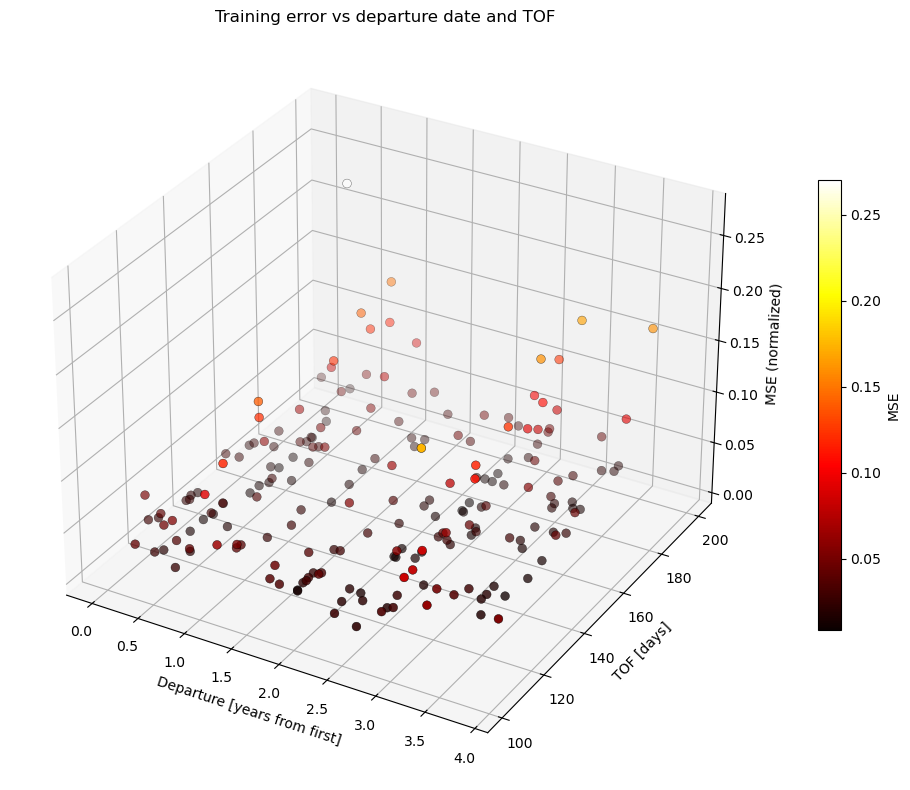

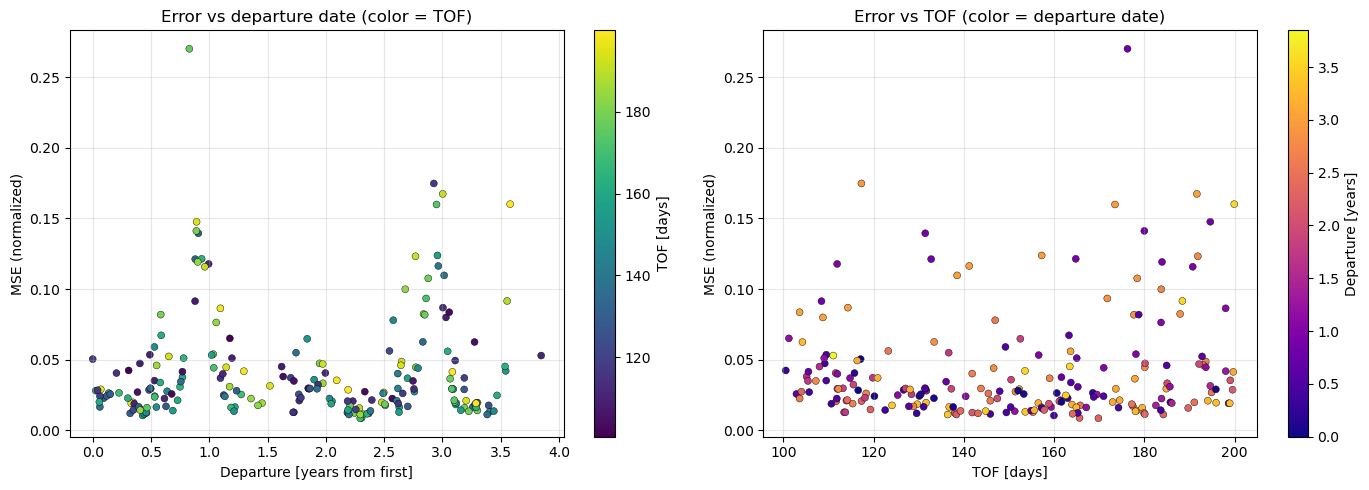

Worst 5 training samples:
  sample 24: MSE=0.1599, dep=2.95yr, tof=173d, angle=130.5°
  sample 92: MSE=0.1601, dep=3.58yr, tof=200d, angle=55.1°
  sample 17: MSE=0.1674, dep=3.00yr, tof=192d, angle=129.8°
  sample 180: MSE=0.1748, dep=2.93yr, tof=117d, angle=108.7°
  sample 60: MSE=0.2701, dep=0.83yr, tof=176d, angle=135.6°
Best 5 training samples:
  sample 112: MSE=0.0086, dep=2.29yr, tof=170d, angle=105.3°
  sample 102: MSE=0.0088, dep=2.31yr, tof=166d, angle=109.5°
  sample 50: MSE=0.0105, dep=0.43yr, tof=160d, angle=154.4°
  sample 61: MSE=0.0112, dep=3.38yr, tof=136d, angle=39.1°
  sample 176: MSE=0.0112, dep=2.30yr, tof=184d, angle=98.8°


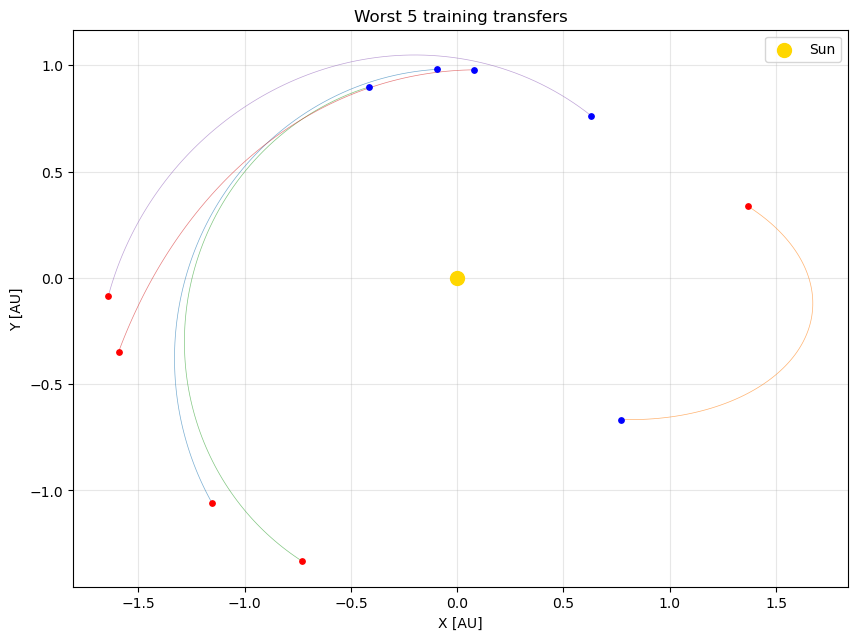

In [40]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

model.load_state_dict(best_state)
def plot_transfers(lamb, soi, sample_indices=None, title="Lambert transfers (XY plane)"):
    """
    lamb: (M, N+1, 6)
    soi:  (M, 2)
    sample_indices: which samples to plot, default all
    """
    AU = 1.496e11
    if sample_indices is None:
        sample_indices = range(lamb.shape[0])
    
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.scatter(0, 0, s=100, color="gold", zorder=10, label="Sun")
    
    for i in sample_indices:
        x = lamb[i, :, 0] / AU
        y = lamb[i, :, 1] / AU
        ax.plot(x, y, linewidth=0.5, alpha=0.6)
        ax.scatter(x[0], y[0], s=15, color="blue", zorder=5)   # departure
        ax.scatter(x[-1], y[-1], s=15, color="red", zorder=5)   # arrival
    
    ax.set_xlabel("X [AU]")
    ax.set_ylabel("Y [AU]")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    ax.legend()
    plt.show()


# ---- Predict on training set ----
with torch.no_grad():
    Y_pred_tr = model(X_tr).cpu().numpy()
Y_true_tr = Y_tr.cpu().numpy()

mse_per_sample = np.mean((Y_pred_tr - Y_true_tr) ** 2, axis=(1, 2))

tr_deps = deps[:n_train]
tr_tofs = tofs[:n_train]
dep_years = (tr_deps - deps.min()) / (365.25 * 86400)

# ---- 1. 3D scatter ----
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(dep_years, tr_tofs, mse_per_sample,
                c=mse_per_sample, cmap='hot', s=40, edgecolors='k', linewidth=0.3)
ax.set_xlabel("Departure [years from first]")
ax.set_ylabel("TOF [days]")
ax.set_zlabel("MSE (normalized)")
ax.set_title("Training error vs departure date and TOF")
fig.colorbar(sc, shrink=0.6, label="MSE")
plt.tight_layout()
plt.show()

# ---- 2. Two 2D scatter plots ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(dep_years, mse_per_sample, c=tr_tofs, cmap='viridis', s=25, edgecolors='k', linewidth=0.3)
axes[0].set_xlabel("Departure [years from first]")
axes[0].set_ylabel("MSE (normalized)")
axes[0].set_title("Error vs departure date (color = TOF)")
sm0 = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(tr_tofs.min(), tr_tofs.max()))
fig.colorbar(sm0, ax=axes[0], label="TOF [days]")

axes[1].scatter(tr_tofs, mse_per_sample, c=dep_years, cmap='plasma', s=25, edgecolors='k', linewidth=0.3)
axes[1].set_xlabel("TOF [days]")
axes[1].set_ylabel("MSE (normalized)")
axes[1].set_title("Error vs TOF (color = departure date)")
sm1 = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(dep_years.min(), dep_years.max()))
fig.colorbar(sm1, ax=axes[1], label="Departure [years]")

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---- 3. Worst and best samples ----
idx_worst = np.argsort(mse_per_sample)[-5:]
idx_best = np.argsort(mse_per_sample)[:5]
print("Worst 5 training samples:")
for i in idx_worst:
    print(f"  sample {i}: MSE={mse_per_sample[i]:.4f}, dep={dep_years[i]:.2f}yr, tof={tr_tofs[i]:.0f}d, angle={angles[i]:.1f}°")
print("Best 5 training samples:")
for i in idx_best:
    print(f"  sample {i}: MSE={mse_per_sample[i]:.4f}, dep={dep_years[i]:.2f}yr, tof={tr_tofs[i]:.0f}d, angle={angles[i]:.1f}°")

# ---- 4. Plot worst trajectories ----
plot_transfers(lamb, soi, sample_indices=idx_worst, title="Worst 5 training transfers")

Predict zero:  1.0219
Predict mean:  0.9162
FNO:           0.0656
Improvement over zero: 93.6%
Improvement over mean: 92.8%

Sample 0:
  True total Dv:      93.57 m/s
  Predicted total Dv: 96.93 m/s
  Dv error:           3.36 m/s (3.6%)


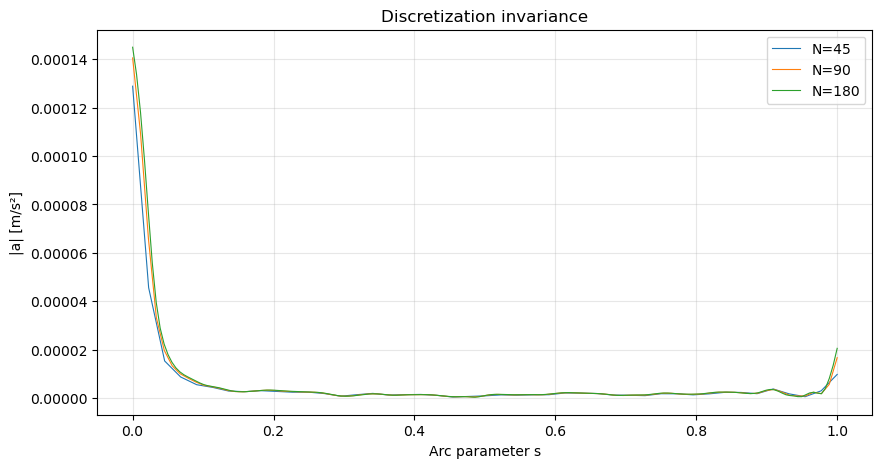

In [ ]:
# ---- 1. Baseline comparison: is FNO better than predicting zero ----
zero_pred = torch.zeros_like(Y_vl)
mean_pred = Y_tr.mean(dim=0, keepdim=True).expand_as(Y_vl)

loss_zero = model.loss(Y_vl, zero_pred).item()
loss_mean = model.loss(Y_vl, mean_pred).item()
loss_fno  = best_val

print(f"Predict zero:  {loss_zero:.4f}")
print(f"Predict mean:  {loss_mean:.4f}")
print(f"FNO:           {loss_fno:.4f}")
print(f"Improvement over zero: {100*(1 - loss_fno/loss_zero):.1f}%")
print(f"Improvement over mean: {100*(1 - loss_fno/loss_mean):.1f}%")

# ---- 2. Physical validation: do predictions produce valid corrections ----
# Denormalize a validation sample and convert back to Dv
model.load_state_dict(best_state)
with torch.no_grad():
    Y_pred_norm = model(X_vl).cpu().numpy()

# Denormalize
Y_pred_phys = Y_pred_norm * Y_std[0, 0, :] + Y_mean[0, 0, :]  # acceleration [m/s^2]
Y_true_phys = Y_vl.cpu().numpy() * Y_std[0, 0, :] + Y_mean[0, 0, :]

# Convert to Dv
sample = 0
arc_dt = arc_lens[sample]  # not filtered — use the right index
pred_dv = np.linalg.norm(Y_pred_phys[sample], axis=1) * arc_dt
true_dv = np.linalg.norm(Y_true_phys[sample], axis=1) * arc_dt

print(f"\nSample {sample}:")
print(f"  True total Dv:      {true_dv.sum():.2f} m/s")
print(f"  Predicted total Dv: {pred_dv.sum():.2f} m/s")
print(f"  Dv error:           {abs(true_dv.sum() - pred_dv.sum()):.2f} m/s ({100*abs(true_dv.sum()-pred_dv.sum())/true_dv.sum():.1f}%)")

# ---- 3. Discretization invariance----
# Resample a validation Lambert arc at different N and predict
from scipy.interpolate import interp1d

val_idx = 0
s_orig = np.linspace(0, 1, N)
x_orig = X_raw[n_train + val_idx]

plt.figure(figsize=(10, 5))
for new_N in [45, 90, 180]:
    s_new = np.linspace(0, 1, new_N)
    x_new = interp1d(s_orig, x_orig, axis=0)(s_new)  # linear, not cubic
    x_norm = (x_new - X_mean[0, 0, :]) / X_std[0, 0, :]
    x_t = torch.tensor(x_norm, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        y = model(x_t).cpu().numpy()[0]
    y_phys = y * Y_std[0, 0, :] + Y_mean[0, 0, :]

    plt.plot(s_new, np.linalg.norm(y_phys, axis=1), label=f"N={new_N}", linewidth=0.8)

plt.xlabel("Arc parameter s")
plt.ylabel("|a| [m/s²]")
plt.title("Discretization invariance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

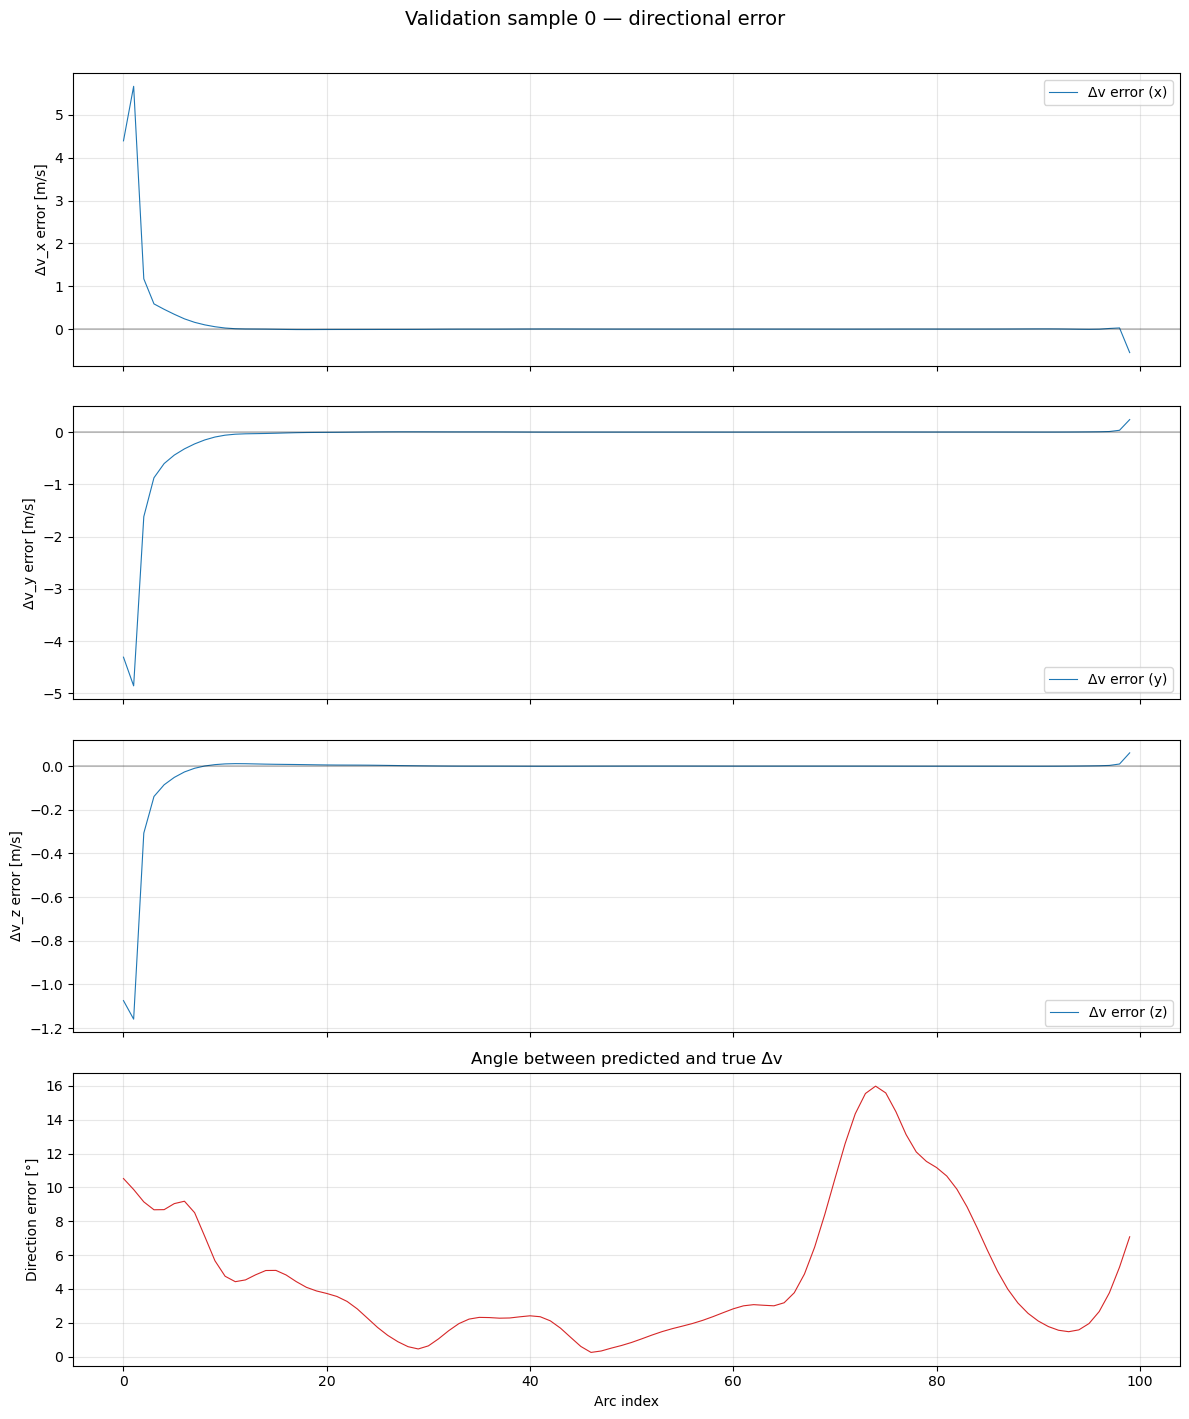

Mean angular error:   4.8°
Median angular error: 3.1°
Max angular error:    16.0°

Per-component RMS error [m/s]:
  x: 7.3362e-01
  y: 6.8079e-01
  z: 1.6203e-01


In [72]:
# ---- Directional error analysis ----
model.load_state_dict(best_state)
with torch.no_grad():
    y_pred_norm = model(X_vl[val_idx:val_idx+1]).cpu().numpy()[0]  # (100, 3)

dv_pred = (pred_dir * pred_mag[:, None] * arc_lens[glob_idx]).astype(np.float64)
dv_true = corr[glob_idx]  # (100, 3)

# Angle between true and predicted Dv at each arc [degrees]
dot = np.sum(dv_pred * dv_true, axis=1)
norm_pred = np.linalg.norm(dv_pred, axis=1) + 1e-30
norm_true = np.linalg.norm(dv_true, axis=1) + 1e-30
cos_angle = np.clip(dot / (norm_pred * norm_true), -1, 1)
angle_err = np.degrees(np.arccos(cos_angle))

# Per-component signed error
err = dv_pred - dv_true  # (100, 3)

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

# Component-wise signed error
labels = ["x", "y", "z"]
for k in range(3):
    axes[k].plot(np.arange(N), err[:, k], linewidth=0.8, label=f"Δv error ({labels[k]})")
    axes[k].axhline(0, color='k', linewidth=0.3)
    axes[k].set_ylabel(f"Δv_{labels[k]} error [m/s]")
    axes[k].grid(True, alpha=0.3)
    axes[k].legend()

# Angular error
axes[3].plot(np.arange(N), angle_err, linewidth=0.8, color='tab:red')
axes[3].set_ylabel("Direction error [°]")
axes[3].set_xlabel("Arc index")
axes[3].set_title("Angle between predicted and true Δv")
axes[3].grid(True, alpha=0.3)

fig.suptitle(f"Validation sample {val_idx} — directional error", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Summary
print(f"Mean angular error:   {np.nanmean(angle_err):.1f}°")
print(f"Median angular error: {np.nanmedian(angle_err):.1f}°")
print(f"Max angular error:    {np.nanmax(angle_err):.1f}°")
print(f"\nPer-component RMS error [m/s]:")
for k in range(3):
    print(f"  {labels[k]}: {np.sqrt(np.mean(err[:, k]**2)):.4e}")

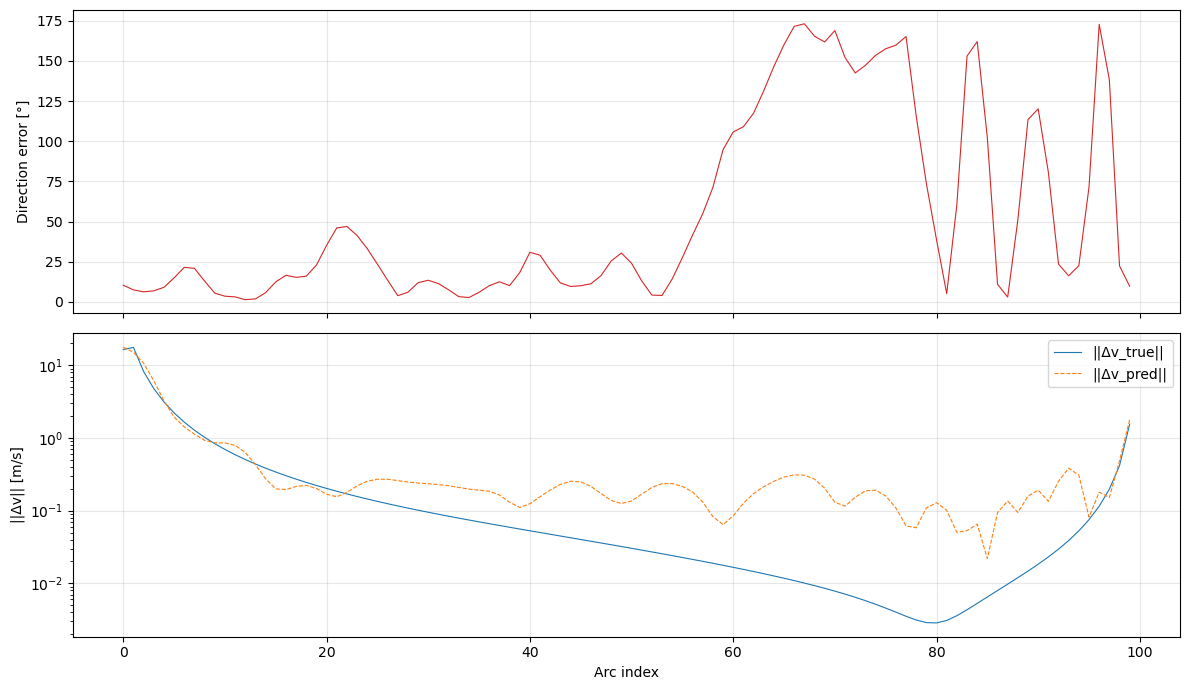

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(np.arange(N), angle_err, linewidth=0.8, color='tab:red')
axes[0].set_ylabel("Direction error [°]")
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(np.arange(N), norm_true, linewidth=0.8, color='tab:blue', label="||Δv_true||")
axes[1].semilogy(np.arange(N), norm_pred, linewidth=0.8, color='tab:orange', linestyle="--", label="||Δv_pred||")
axes[1].set_ylabel("||Δv|| [m/s]")
axes[1].set_xlabel("Arc index")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [74]:
import torch
import torch.nn.functional as F
import numpy as np
from models import FNO, device

# ---- Build targets: log-magnitude + unit direction ----
X_raw = lamb[:, :-1, :]                            # (M, 100, 6)
Y_raw = corr / arc_lens[:, None, None]             # (M, 100, 3) acceleration

mag = np.linalg.norm(Y_raw, axis=2, keepdims=True) # (M, 100, 1)
log_mag = np.log10(mag + 1e-30)                     # (M, 100, 1)
unit_dir = Y_raw / (mag + 1e-30)                    # (M, 100, 3)

# Target: [log_mag, dir_x, dir_y, dir_z] = 4 channels
Y_combined = np.concatenate([log_mag, unit_dir], axis=2)  # (M, 100, 4)

# ---- Normalize inputs only (output has natural scale) ----
X_mean = X_raw.mean(axis=(0, 1), keepdims=True)
X_std  = X_raw.std(axis=(0, 1), keepdims=True) + 1e-10

# Log-magnitude normalization
lm_mean = log_mag.mean()
lm_std  = log_mag.std() + 1e-10

X = torch.tensor((X_raw - X_mean) / X_std, dtype=torch.float32)
# Target: normalized log-mag + raw unit direction (already [-1, 1])
Y_target_mag = torch.tensor((log_mag - lm_mean) / lm_std, dtype=torch.float32)
Y_target_dir = torch.tensor(unit_dir, dtype=torch.float32)

n_train = int(0.85 * M)
X_tr = X[:n_train].to(device)
X_vl = X[n_train:].to(device)
mag_tr = Y_target_mag[:n_train].to(device)
mag_vl = Y_target_mag[n_train:].to(device)
dir_tr = Y_target_dir[:n_train].to(device)
dir_vl = Y_target_dir[n_train:].to(device)

# ---- Model: 6 in, 4 out (1 log-mag + 3 direction) ----
model = FNO(modes=12, latent_width=24, in_channels=6, out_channels=4, n_layers=2)

def combined_loss(pred, mag_true, dir_true, lambda_dir=5.0):
    pred_mag = pred[:, :, 0:1]  # (B, N, 1)
    pred_dir = pred[:, :, 1:4]  # (B, N, 3)

    # MSE on log-magnitude
    loss_mag = torch.mean((pred_mag - mag_true) ** 2)

    # Cosine similarity loss on direction (1 - cos_sim)
    cos_sim = F.cosine_similarity(pred_dir, dir_true, dim=2)  # (B, N)
    loss_dir = torch.mean(1.0 - cos_sim)

    return loss_mag + lambda_dir * loss_dir, loss_mag.item(), loss_dir.item()

# ---- Train ----
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
restart_at1 = 4000
restart_at2 = 8000

total_epochs = 10000

train_l, val_l = [], []
best_val = float('inf')
best_state = None

for epoch in range(total_epochs):
    if epoch == restart_at1 or epoch == restart_at2:
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    model.train()
    pred = model(X_tr)
    loss, lm, ld = combined_loss(pred, mag_tr, dir_tr)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        vp = model(X_vl)
        vloss, vlm, vld = combined_loss(vp, mag_vl, dir_vl)
    train_l.append(loss.item())
    val_l.append(vloss.item())

    if vloss.item() < best_val:
        best_val = vloss.item()
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 1000 == 0:
        print(f"[{epoch+1}] train={loss.item():.4f} (mag={lm:.4f} dir={ld:.4f})  "
              f"val={vloss.item():.4f} (mag={vlm:.4f} dir={vld:.4f})")

model.load_state_dict(best_state)
print(f"Best val loss: {best_val:.4f}")


with torch.no_grad():
    pred = model(X_vl[0:1]).cpu().numpy()[0]  # (100, 4)

pred_log_mag = pred[:, 0] * lm_std + lm_mean          # denormalize
pred_mag = 10 ** pred_log_mag                           # (100,)
pred_dir = pred[:, 1:4]                                 # (100, 3)
pred_dir = pred_dir / (np.linalg.norm(pred_dir, axis=1, keepdims=True) + 1e-30)  # re-normalize to unit

dv_pred = pred_dir * pred_mag[:, None] * arc_lens[glob_idx]  # (100, 3) in m/s

[1000] train=0.2102 (mag=0.0382 dir=0.0344)  val=0.2207 (mag=0.0410 dir=0.0359)
[2000] train=0.0906 (mag=0.0233 dir=0.0135)  val=0.1407 (mag=0.0252 dir=0.0231)
[3000] train=0.0525 (mag=0.0175 dir=0.0070)  val=0.1182 (mag=0.0189 dir=0.0199)
[4000] train=0.0374 (mag=0.0146 dir=0.0046)  val=0.0952 (mag=0.0155 dir=0.0159)
[5000] train=0.0292 (mag=0.0120 dir=0.0035)  val=0.0738 (mag=0.0129 dir=0.0122)
[6000] train=0.0237 (mag=0.0097 dir=0.0028)  val=0.0735 (mag=0.0109 dir=0.0125)
[7000] train=0.0212 (mag=0.0081 dir=0.0026)  val=0.0730 (mag=0.0093 dir=0.0127)
[8000] train=0.0180 (mag=0.0070 dir=0.0022)  val=0.0702 (mag=0.0084 dir=0.0124)
[9000] train=0.0152 (mag=0.0064 dir=0.0018)  val=0.0717 (mag=0.0079 dir=0.0127)
[10000] train=0.0137 (mag=0.0058 dir=0.0016)  val=0.0675 (mag=0.0076 dir=0.0120)
Best val loss: 0.0648


Arc   0: TRUE=2.33e-04  HYBRID=2.33e-04  match=True
Arc   1: TRUE=7.22e-05  HYBRID=7.22e-05  match=True
Arc   2: TRUE=1.24e-04  HYBRID=1.24e-04  match=True
Arc   3: TRUE=1.45e-05  HYBRID=1.45e-05  match=True
Arc   4: TRUE=8.53e-05  HYBRID=8.53e-05  match=True
Arc  14: TRUE=1.22e-04  HYBRID=1.22e-04  match=True
Arc  15: TRUE=1.83e-04  HYBRID=5.52e+03  match=False

TRUE:
  Final ||dr|| = 3.15e-05 m
  Final ||dv|| = 2.46e+00 m/s
  Max   ||dr|| = 3.91e-04 m
  Total Dv     = 54.92 m/s

HYBRID:
  Final ||dr|| = 5.41e+06 m
  Final ||dv|| = 1.42e+00 m/s
  Max   ||dr|| = 5.41e+06 m
  Total Dv     = 54.36 m/s

FNO:
  Final ||dr|| = 4.91e+08 m
  Final ||dv|| = 8.47e+01 m/s
  Max   ||dr|| = 4.91e+08 m
  Total Dv     = 15.72 m/s

NONE:
  Final ||dr|| = 6.40e+08 m
  Final ||dv|| = 1.10e+02 m/s
  Max   ||dr|| = 6.40e+08 m
  Total Dv     = 0.00 m/s


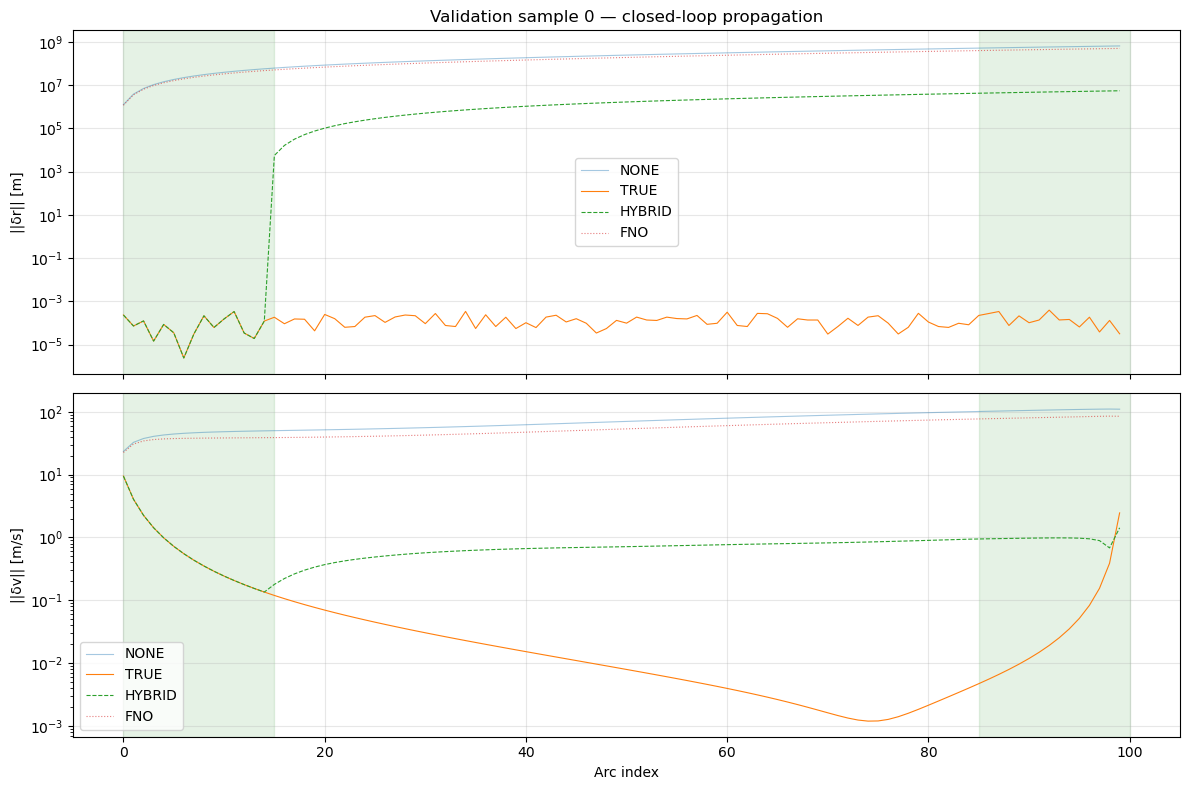

In [75]:
model.load_state_dict(best_state)

val_idx = 0
glob_idx = n_train + val_idx

# ---- Reconstruct FNO Dv ----
with torch.no_grad():
    pred = model(X_vl[val_idx:val_idx+1]).cpu().numpy()[0]

pred_log_mag = pred[:, 0] * lm_std + lm_mean
pred_mag = 10 ** pred_log_mag
pred_dir = pred[:, 1:4]
pred_dir = pred_dir / (np.linalg.norm(pred_dir, axis=1, keepdims=True) + 1e-30)
dv_pred = (pred_dir * pred_mag[:, None] * arc_lens[glob_idx]).astype(np.float64)
dv_true = corr[glob_idx]

boundary = 15
dv_hybrid = dv_pred.copy()
dv_hybrid[:boundary] = dv_true[:boundary]
dv_hybrid[-boundary:] = dv_true[-boundary:]

# ---- All four variants in parallel, each with own state ----
bodies = create_simulation_bodies()
lambert_eph = get_lambert_problem_result(
    bodies, "Mars", deps[glob_idx], deps[glob_idx] + tofs[glob_idx] * 86400.0)
arc_epochs = np.linspace(soi[glob_idx, 0], soi[glob_idx, 1], N + 1)

dv_sets = {
    "TRUE":    dv_true,
    "HYBRID":  dv_hybrid,
    "FNO":     dv_pred,
    "NONE":    np.zeros((N, 3)),
}

state_corrs = {k: np.zeros(6) for k in dv_sets}
pos_devs = {k: np.zeros(N) for k in dv_sets}
vel_devs = {k: np.zeros(N) for k in dv_sets}

for i in range(N):
    t0 = arc_epochs[i]
    tf = arc_epochs[i + 1]
    term = propagation_setup.propagator.time_termination(tf)

    for name, dv_arr in dv_sets.items():
        impulse = np.concatenate([np.zeros(3), dv_arr[i]])
        arc_corr = state_corrs[name] + impulse

        sim = propagate_trajectory(
            t0, term, bodies, lambert_eph,
            initial_state_correction=arc_corr,
            use_rsw_acceleration=False,
        )
        sh = sim.propagation_results.state_history
        lh = get_lambert_arc_history(lambert_eph, sh)
        sh_arr = np.vstack(list(sh.values()))
        lh_arr = np.vstack(list(lh.values()))
        dx = sh_arr[-1] - lh_arr[-1]

        pos_devs[name][i] = np.linalg.norm(dx[:3])
        vel_devs[name][i] = np.linalg.norm(dx[3:])
        state_corrs[name] = dx.copy()

    if i < 5 or i == boundary - 1 or i == boundary:
        print(f"Arc {i:3d}: TRUE={pos_devs['TRUE'][i]:.2e}  HYBRID={pos_devs['HYBRID'][i]:.2e}  match={np.allclose(pos_devs['TRUE'][i], pos_devs['HYBRID'][i], rtol=1e-6)}")

# ---- Print results ----
for name in dv_sets:
    print(f"\n{name}:")
    print(f"  Final ||dr|| = {pos_devs[name][-1]:.2e} m")
    print(f"  Final ||dv|| = {vel_devs[name][-1]:.2e} m/s")
    print(f"  Max   ||dr|| = {np.max(pos_devs[name]):.2e} m")
    print(f"  Total Dv     = {np.sum(np.linalg.norm(dv_sets[name], axis=1)):.2f} m/s")

# ---- Plot ----
arcs = np.arange(N)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for name, ls, alpha in [("NONE", "-", 0.4), ("TRUE", "-", 1.0), ("HYBRID", "--", 1.0), ("FNO", ":", 0.6)]:
    axes[0].semilogy(arcs, pos_devs[name], label=name, linestyle=ls, linewidth=0.8, alpha=alpha)
    axes[1].semilogy(arcs, vel_devs[name], label=name, linestyle=ls, linewidth=0.8, alpha=alpha)

for ax in axes:
    ax.axvspan(0, boundary, alpha=0.1, color='green')
    ax.axvspan(N - boundary, N, alpha=0.1, color='green')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("||δr|| [m]")
axes[0].set_title(f"Validation sample {val_idx} — closed-loop propagation")
axes[1].set_ylabel("||δv|| [m/s]")
axes[1].set_xlabel("Arc index")
plt.tight_layout()
plt.show()

Arc 0 match: True

TRUE:
  Final ||dr|| = 3.15e-05 m
  Final ||dv|| = 2.46e+00 m/s
  Max   ||dr|| = 3.91e-04 m
  Total Dv     = 54.92 m/s

HYBRID:
  Final ||dr|| = 5.41e+06 m
  Final ||dv|| = 1.42e+00 m/s
  Max   ||dr|| = 5.41e+06 m
  Total Dv     = 54.36 m/s

FNO:
  Final ||dr|| = 4.91e+08 m
  Final ||dv|| = 8.47e+01 m/s
  Max   ||dr|| = 4.91e+08 m
  Total Dv     = 15.72 m/s

NONE:
  Final ||dr|| = 6.40e+08 m
  Final ||dv|| = 1.10e+02 m/s
  Max   ||dr|| = 6.40e+08 m
  Total Dv     = 0.00 m/s


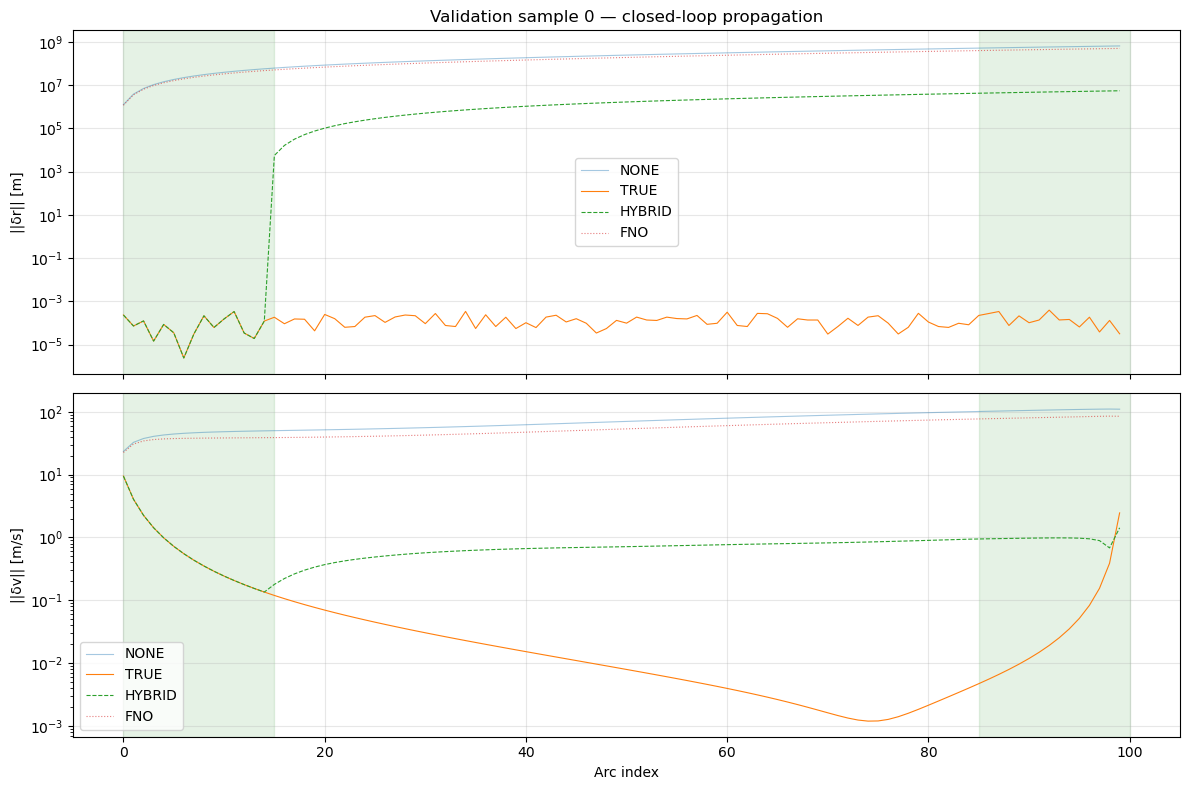


Mean angular error (FNO arcs): 5.6°
Median angular error (FNO arcs): 3.7°
Dv true total:   54.92 m/s
Dv hybrid total: 54.36 m/s
Dv FNO total:    15.72 m/s


In [76]:
model.load_state_dict(best_state)

val_idx = 0
glob_idx = n_train + val_idx

# ---- Reconstruct FNO Dv ----
with torch.no_grad():
    pred = model(X_vl[val_idx:val_idx+1]).cpu().numpy()[0]

pred_log_mag = pred[:, 0] * lm_std + lm_mean
pred_mag = 10 ** pred_log_mag
pred_dir = pred[:, 1:4]
pred_dir = pred_dir / (np.linalg.norm(pred_dir, axis=1, keepdims=True) + 1e-30)
dv_pred = (pred_dir * pred_mag[:, None] * arc_lens[glob_idx]).astype(np.float64)
dv_true = corr[glob_idx]

boundary = 15
dv_hybrid = dv_pred.copy()
dv_hybrid[:boundary] = dv_true[:boundary]
dv_hybrid[-boundary:] = dv_true[-boundary:]

# Verify
print("Arc 0 match:", np.array_equal(dv_true[0], dv_hybrid[0]))

arcs = np.arange(N)

# ---- Propagation ----
bodies = create_simulation_bodies()
lambert_eph = get_lambert_problem_result(
    bodies, "Mars", deps[glob_idx], deps[glob_idx] + tofs[glob_idx] * 86400.0)
arc_epochs = np.linspace(soi[glob_idx, 0], soi[glob_idx, 1], N + 1)

dv_sets = {
    "TRUE":    dv_true,
    "HYBRID":  dv_hybrid,
    "FNO":     dv_pred,
    "NONE":    np.zeros((N, 3)),
}

state_corrs = {k: np.zeros(6) for k in dv_sets}
pos_devs = {k: np.zeros(N) for k in dv_sets}
vel_devs = {k: np.zeros(N) for k in dv_sets}

for i in range(N):
    t0 = arc_epochs[i]
    tf = arc_epochs[i + 1]
    term = propagation_setup.propagator.time_termination(tf)

    for name, dv_arr in dv_sets.items():
        impulse = np.concatenate([np.zeros(3), dv_arr[i]])
        arc_corr = state_corrs[name] + impulse

        sim = propagate_trajectory(
            t0, term, bodies, lambert_eph,
            initial_state_correction=arc_corr,
            use_rsw_acceleration=False,
        )
        sh = sim.propagation_results.state_history
        lh = get_lambert_arc_history(lambert_eph, sh)
        sh_arr = np.vstack(list(sh.values()))
        lh_arr = np.vstack(list(lh.values()))
        dx = sh_arr[-1] - lh_arr[-1]

        pos_devs[name][i] = np.linalg.norm(dx[:3])
        vel_devs[name][i] = np.linalg.norm(dx[3:])
        state_corrs[name] = dx.copy()

# ---- Print results ----
for name in dv_sets:
    print(f"\n{name}:")
    print(f"  Final ||dr|| = {pos_devs[name][-1]:.2e} m")
    print(f"  Final ||dv|| = {vel_devs[name][-1]:.2e} m/s")
    print(f"  Max   ||dr|| = {np.max(pos_devs[name]):.2e} m")
    print(f"  Total Dv     = {np.sum(np.linalg.norm(dv_sets[name], axis=1)):.2f} m/s")

# ---- Plot ----
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for name, ls, alpha in [("NONE", "-", 0.4), ("TRUE", "-", 1.0), ("HYBRID", "--", 1.0), ("FNO", ":", 0.6)]:
    axes[0].semilogy(arcs, pos_devs[name], label=name, linestyle=ls, linewidth=0.8, alpha=alpha)
    axes[1].semilogy(arcs, vel_devs[name], label=name, linestyle=ls, linewidth=0.8, alpha=alpha)

for ax in axes:
    ax.axvspan(0, boundary, alpha=0.1, color='green')
    ax.axvspan(N - boundary, N, alpha=0.1, color='green')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("||δr|| [m]")
axes[0].set_title(f"Validation sample {val_idx} — closed-loop propagation")
axes[1].set_ylabel("||δv|| [m/s]")
axes[1].set_xlabel("Arc index")
plt.tight_layout()
plt.show()

# ---- Angular error (mid-transfer) ----
true_mag = np.linalg.norm(dv_true, axis=1)
pred_mag_dv = np.linalg.norm(dv_pred, axis=1)
dot = np.sum(dv_pred * dv_true, axis=1)
cos_angle = np.clip(dot / (pred_mag_dv * true_mag + 1e-30), -1, 1)
angle_err = np.degrees(np.arccos(cos_angle))

print(f"\nMean angular error (FNO arcs): {np.nanmean(angle_err[boundary:-boundary]):.1f}°")
print(f"Median angular error (FNO arcs): {np.nanmedian(angle_err[boundary:-boundary]):.1f}°")
print(f"Dv true total:   {true_mag.sum():.2f} m/s")
print(f"Dv hybrid total: {np.linalg.norm(dv_hybrid, axis=1).sum():.2f} m/s")
print(f"Dv FNO total:    {pred_mag_dv.sum():.2f} m/s")

In [63]:
# ---- Diagnostic: arc-by-arc for first 20 arcs ----
# Compare TRUE-only vs HYBRID for the boundary region

bodies = create_simulation_bodies()
lambert_eph = get_lambert_problem_result(
    bodies, "Mars",
    deps[glob_idx],
    deps[glob_idx] + tofs[glob_idx] * 86400.0,
)
arc_ep = np.linspace(soi[glob_idx, 0], soi[glob_idx, 1], N + 1)

boundary = 15
dv_true = corr[glob_idx]

state_corr_true = np.zeros(6)
state_corr_hybrid = np.zeros(6)

print(f"{'arc':>4s}  {'TRUE ||dr||':>12s}  {'HYBRID ||dr||':>13s}  {'TRUE dv_x':>12s}  {'HYBRID dv_x':>12s}  {'state_corr match':>16s}")
print("-" * 90)

for i in range(20):
    t0, tf = arc_ep[i], arc_ep[i + 1]
    term = propagation_setup.propagator.time_termination(tf)

    # TRUE
    impulse_t = np.concatenate([np.zeros(3), dv_true[i]])
    sim_t = propagate_trajectory(
        t0, term, bodies, lambert_eph,
        initial_state_correction=state_corr_true + impulse_t,
        use_rsw_acceleration=False,
    )
    sh_t = np.vstack(list(sim_t.propagation_results.state_history.values()))
    lh_t = np.vstack(list(get_lambert_arc_history(lambert_eph, sim_t.propagation_results.state_history).values()))
    dx_t = sh_t[-1] - lh_t[-1]

    # HYBRID (same dv for first 15 arcs)
    if i < boundary:
        dv_h = dv_true[i]
    else:
        dv_h = dv_hybrid[i]

    impulse_h = np.concatenate([np.zeros(3), dv_h])
    sim_h = propagate_trajectory(
        t0, term, bodies, lambert_eph,
        initial_state_correction=state_corr_hybrid + impulse_h,
        use_rsw_acceleration=False,
    )
    sh_h = np.vstack(list(sim_h.propagation_results.state_history.values()))
    lh_h = np.vstack(list(get_lambert_arc_history(lambert_eph, sim_h.propagation_results.state_history).values()))
    dx_h = sh_h[-1] - lh_h[-1]

    match = np.allclose(state_corr_true, state_corr_hybrid, atol=1e-10)

    print(f"{i:4d}  {np.linalg.norm(dx_t[:3]):12.4e}  {np.linalg.norm(dx_h[:3]):13.4e}  "
          f"{dv_true[i, 0]:12.4e}  {dv_h[0]:12.4e}  {str(match):>16s}")

    state_corr_true = dx_t.copy()
    state_corr_hybrid = dx_h.copy()

 arc   TRUE ||dr||  HYBRID ||dr||     TRUE dv_x   HYBRID dv_x  state_corr match
------------------------------------------------------------------------------------------
   0    2.3287e-04     2.3287e-04   -1.1777e+01   -1.1777e+01              True
   1    7.2242e-05     7.2242e-05   -1.2422e+01   -1.2422e+01              True
   2    1.2391e-04     1.2391e-04   -5.7174e+00   -5.7174e+00              True
   3    1.4483e-05     1.4483e-05   -3.3019e+00   -3.3019e+00              True
   4    8.5278e-05     8.5278e-05   -2.1530e+00   -2.1530e+00              True
   5    3.5180e-05     3.5180e-05   -1.5156e+00   -1.5156e+00              True
   6    2.3961e-06     2.3961e-06   -1.1249e+00   -1.1249e+00              True
   7    3.0763e-05     3.0763e-05   -8.6797e-01   -8.6797e-01              True
   8    2.1404e-04     2.1404e-04   -6.8993e-01   -6.8993e-01              True
   9    6.1512e-05     6.1512e-05   -5.6144e-01   -5.6144e-01              True
  10    1.5279e-04     1.5279


TRUE corrections:
  Final ||dr|| = 6.11e-05 m
  Final ||dv|| = 2.71e+00 m/s
  Max   ||dr|| = 4.58e-04 m
  Total Dv     = 66.93 m/s

FNO corrections:
  Final ||dr|| = 1.59e+08 m
  Final ||dv|| = 2.40e+01 m/s
  Max   ||dr|| = 1.59e+08 m
  Total Dv     = 79.37 m/s

NO corrections:
  Final ||dr|| = 9.02e+08 m
  Final ||dv|| = 1.51e+02 m/s
  Max   ||dr|| = 9.02e+08 m
  Total Dv     = 0.00 m/s


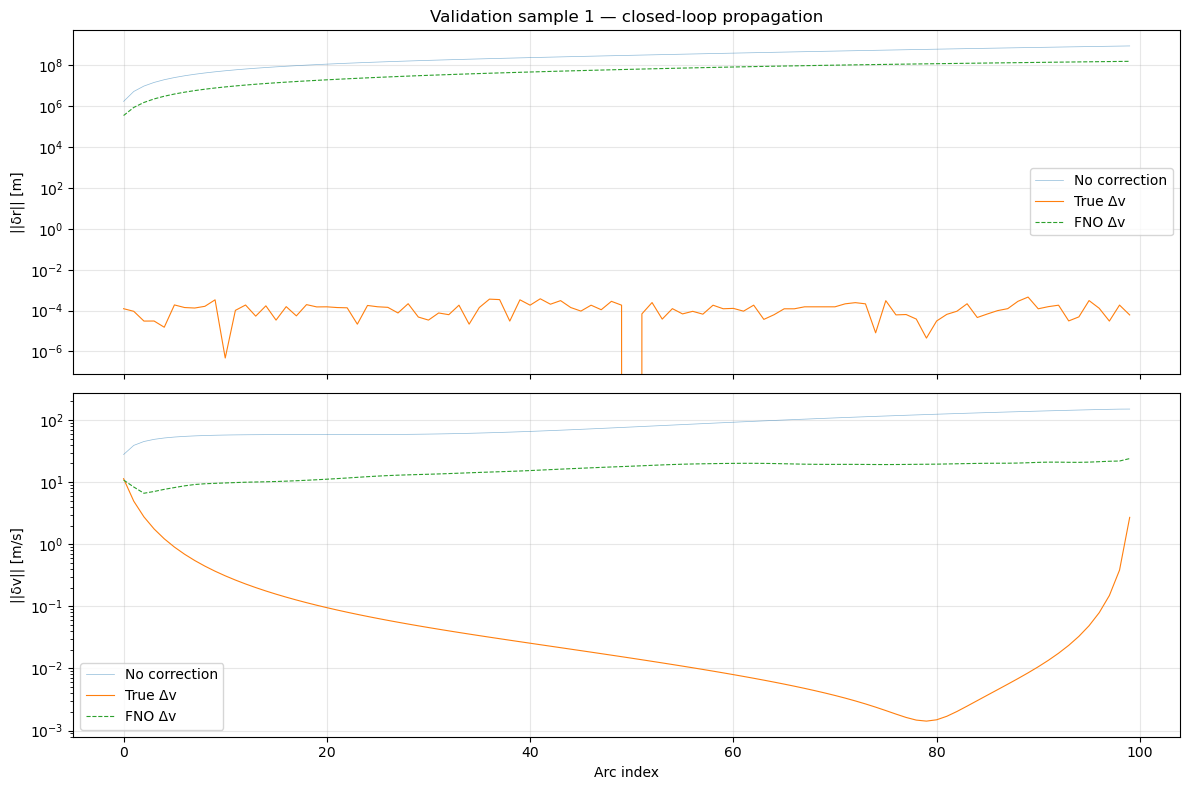

In [ ]:
from earth_mars_transfer_helpers import *
from Earth_mars_solver_functions import *
from tudatpy.dynamics import propagation_setup
import numpy as np

val_idx = 1
glob_idx = n_train + val_idx

# ---- Get FNO prediction and denormalize ----
model.load_state_dict(best_state)
with torch.no_grad():
    y_pred_norm = model(X_vl[val_idx:val_idx+1]).cpu().numpy()[0]  # (100, 3)

dv_pred_full = (y_pred_norm * Y_std[0, 0, :] + Y_mean[0, 0, :]) * arc_lens[glob_idx]

# ---- Full correction arrays (100 arcs) ----
dv_true_full = corr[glob_idx]  # (100, 3)

# ---- Propagation ----
bodies = create_simulation_bodies()
lambert_eph = get_lambert_problem_result(
    bodies, "Mars",
    deps[glob_idx],
    deps[glob_idx] + tofs[glob_idx] * 86400.0,
)
arc_epochs = np.linspace(soi[glob_idx, 0], soi[glob_idx, 1], N + 1)

def propagate_with_corrections(dv_array, label):
    state_correction = np.zeros(6)
    pos_dev = np.zeros(N)
    vel_dev = np.zeros(N)

    for i in range(N):
        t0 = arc_epochs[i]
        tf = arc_epochs[i + 1]
        term = propagation_setup.propagator.time_termination(tf)

        impulse = np.concatenate([np.zeros(3), dv_array[i]])
        arc_corr = state_correction + impulse

        sim = propagate_trajectory(
            t0, term, bodies, lambert_eph,
            initial_state_correction=arc_corr,
            use_rsw_acceleration=False,
        )
        sh = sim.propagation_results.state_history
        lh = get_lambert_arc_history(lambert_eph, sh)
        sh_arr = np.vstack(list(sh.values()))
        lh_arr = np.vstack(list(lh.values()))

        dx = sh_arr[-1] - lh_arr[-1]
        pos_dev[i] = np.linalg.norm(dx[:3])
        vel_dev[i] = np.linalg.norm(dx[3:])
        state_correction = dx.copy()

    print(f"\n{label}:")
    print(f"  Final ||dr|| = {pos_dev[-1]:.2e} m")
    print(f"  Final ||dv|| = {vel_dev[-1]:.2e} m/s")
    print(f"  Max   ||dr|| = {np.max(pos_dev):.2e} m")
    print(f"  Total Dv     = {np.sum(np.linalg.norm(dv_array, axis=1)):.2f} m/s")
    return pos_dev, vel_dev

pos_true, vel_true = propagate_with_corrections(dv_true_full, "TRUE corrections")
pos_pred, vel_pred = propagate_with_corrections(dv_pred_full, "FNO corrections")
pos_none, vel_none = propagate_with_corrections(np.zeros((N, 3)), "NO corrections")

# ---- Plot ----
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
arcs = np.arange(N)

axes[0].semilogy(arcs, pos_none, label="No correction", linewidth=0.5, alpha=0.5)
axes[0].semilogy(arcs, pos_true, label="True Δv", linewidth=0.8)
axes[0].semilogy(arcs, pos_pred, label="FNO Δv", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("||δr|| [m]")
axes[0].set_title(f"Validation sample {val_idx} — closed-loop propagation")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(arcs, vel_none, label="No correction", linewidth=0.5, alpha=0.5)
axes[1].semilogy(arcs, vel_true, label="True Δv", linewidth=0.8)
axes[1].semilogy(arcs, vel_pred, label="FNO Δv", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("||δv|| [m/s]")
axes[1].set_xlabel("Arc index")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
n_train = 64
model = FNO(modes=12, latent_width=24, in_channels=6, out_channels=3, n_layers=2)
# Compute transfer angle for each existing sample
angles = np.zeros(M)
for i in range(M):
    r1 = lamb[i, 0, :3]
    r2 = lamb[i, -1, :3]
    cos_a = np.dot(r1, r2) / (np.linalg.norm(r1) * np.linalg.norm(r2))
    angles[i] = np.degrees(np.arccos(np.clip(cos_a, -1, 1)))

mask = angles > 50
print(f"Keeping {mask.sum()} / {M} samples")

lamb_clean = lamb[mask]
corr_clean = corr[mask]
arc_lens_clean = arc_lens[mask]
soi_clean = soi[mask]

Keeping 56 / 80 samples


In [33]:
# Per-sample normalization (replace the global normalization block)
X_raw = lamb_clean[:, :-1, :]                          # (80, 100, 6)
Y_raw = corr_clean / arc_lens_clean[:, None, None]           # (80, 100, 3)

X_mean = X_raw.mean(axis=1, keepdims=True)        # (80, 1, 6) — per trajectory
X_std  = X_raw.std(axis=1, keepdims=True) + 1e-10
Y_mean = Y_raw.mean(axis=1, keepdims=True)        # (80, 1, 3)
Y_std  = Y_raw.std(axis=1, keepdims=True) + 1e-10

X = torch.tensor((X_raw - X_mean) / X_std, dtype=torch.float32)
Y = torch.tensor((Y_raw - Y_mean) / Y_std, dtype=torch.float32)

In [34]:
n_train = 40
train_losses, val_losses = model.train_model(
    X[:n_train], Y[:n_train], epochs=2000, lr=1e-3,
    validation_data=(X[n_train:], Y[n_train:]), loss_tracking=True
)

Training Epoch:  26%|██▌       | 512/2000 [00:05<00:14, 100.77it/s, train_loss=0.016, val_loss=2.61] 


KeyboardInterrupt: 

In [13]:



model = FNO(modes=12, latent_width=24, in_channels=6, out_channels=3, n_layers=2)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=3000)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tr = X[:64].to(device)
Y_tr = Y[:64].to(device)
X_vl = X[64:].to(device)
Y_vl = Y[64:].to(device)

train_losses, val_losses = [], []
for epoch in range(3000):
    model.train()
    pred = model(X_tr)
    loss = model.loss(Y_tr, pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    with torch.no_grad():
        vl = model.loss(Y_vl, model(X_vl))
    
    train_losses.append(loss.item())
    val_losses.append(vl.item())
    
    if (epoch + 1) % 500 == 0:
        print(f"[{epoch+1}] train={loss.item():.4f}  val={vl.item():.4f}  lr={scheduler.get_last_lr()[0]:.2e}")

[500] train=1.0147  val=1.1626  lr=9.33e-04
[1000] train=0.7474  val=0.8665  lr=7.50e-04
[1500] train=0.6790  val=0.7897  lr=5.00e-04
[2000] train=0.6514  val=0.7581  lr=2.50e-04
[2500] train=0.6406  val=0.7457  lr=6.70e-05
[3000] train=0.6388  val=0.7436  lr=0.00e+00


In [18]:
from models import FNN
M, N = 80, 100

# Input: state_start(6) + state_end(6) + arc_duration(1) + arc_epoch(1) = 14
state_start = lamb[:, :-1, :]                         # (80, 100, 6)
state_end   = lamb[:, 1:, :]                          # (80, 100, 6)
durations   = arc_lens[:, None, None] * np.ones((M, N, 1))  # (80, 100, 1)

arc_epoch_starts = np.zeros((M, N, 1))
for i in range(M):
    arc_epoch_starts[i, :, 0] = np.linspace(soi[i, 0], soi[i, 1], N + 1)[:-1]

X_local = np.concatenate([state_start, state_end, durations, arc_epoch_starts], axis=2)  # (80, 100, 14)
Y_local = corr.copy()                                                  # (80, 100, 3) — Dv

# Flatten: each arc is one sample
X_flat = X_local.reshape(-1, 14)    # (8000, 14)
Y_flat = Y_local.reshape(-1, 3)     # (8000, 3)

# Global normalization
X_m, X_s = X_flat.mean(axis=0, keepdims=True), X_flat.std(axis=0, keepdims=True) + 1e-10
Y_m, Y_s = Y_flat.mean(axis=0, keepdims=True), Y_flat.std(axis=0, keepdims=True) + 1e-10

X_n = torch.tensor((X_flat - X_m) / X_s, dtype=torch.float32).to(device)
Y_n = torch.tensor((Y_flat - Y_m) / Y_s, dtype=torch.float32).to(device)

# Split: first 64 trajectories train, last 16 val
n_train = 64 * N  # 6400
X_tr, Y_tr = X_n[:n_train], Y_n[:n_train]
X_vl, Y_vl = X_n[n_train:], Y_n[n_train:]

# ---- Train ----
model_local = FNN([14, 32, 32, 3])
optimizer = torch.optim.Adam(model_local.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5000)

train_l, val_l = [], []
best_val = float('inf')
best_state = None

for epoch in range(5000):
    model_local.train()
    pred = model_local(X_tr)
    loss = model_local.loss_fn(pred, Y_tr)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    with torch.no_grad():
        vl = model_local.loss_fn(model_local(X_vl), Y_vl)
    train_l.append(loss.item())
    val_l.append(vl.item())

    if vl.item() < best_val:
        best_val = vl.item()
        best_state = {k: v.clone() for k, v in model_local.state_dict().items()}

    if (epoch + 1) % 1000 == 0:
        print(f"[{epoch+1}] train={loss.item():.4f}  val={vl.item():.4f}  lr={scheduler.get_last_lr()[0]:.2e}")

model_local.load_state_dict(best_state)
print(f"Best val loss: {best_val:.4f}")

[1000] train=0.3062  val=0.5254  lr=9.05e-04
[2000] train=0.2115  val=0.4257  lr=6.55e-04
[3000] train=0.1817  val=0.3914  lr=3.45e-04
[4000] train=0.1716  val=0.3881  lr=9.55e-05
[5000] train=0.1700  val=0.3879  lr=0.00e+00
Best val loss: 0.3867


NameError: name 'train_losses' is not defined

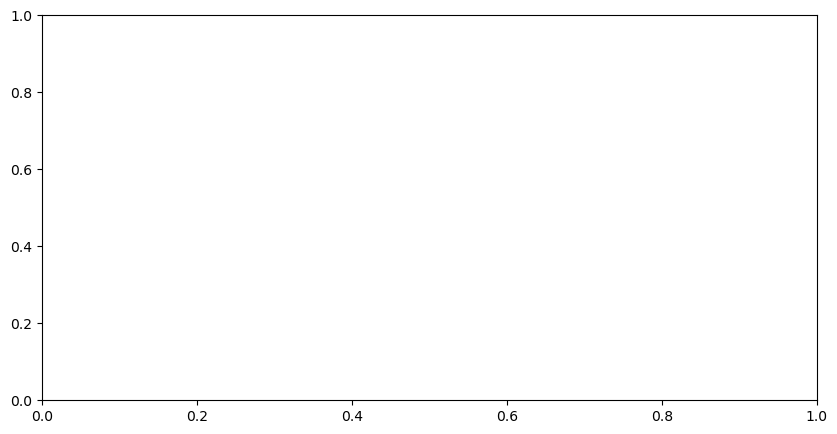

In [5]:
import matplotlib.pyplot as plt

# ---- 1. Loss curves ----
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(train_losses, label="Train", linewidth=0.8)
ax.semilogy(val_losses, label="Validation", linewidth=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training convergence")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# ---- 2. Predict on validation set ----
Y_pred = model.predict(X[16:])  # (4, 100, 3)
Y_val = Y[16:].to(Y_pred.device)

# ---- 3. Per-sample comparison: predicted vs true correction acceleration ----
comp_labels = ["R (radial)", "S (along-track)", "W (cross-track)"]
for sample_idx in range(Y_val.shape[0]):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    arcs = np.arange(Y_val.shape[1])

    for k, ax in enumerate(axes):
        true = Y_val[sample_idx, :, k].cpu().numpy()
        pred = Y_pred[sample_idx, :, k].cpu().numpy()
        ax.plot(arcs, true, label="True", linewidth=0.8)
        ax.plot(arcs, pred, label="Predicted", linewidth=0.8, linestyle="--")
        ax.set_ylabel(comp_labels[k])
        ax.grid(True, alpha=0.3)
        if k == 0:
            ax.legend()

    axes[-1].set_xlabel("Arc index")
    axes[0].set_title(f"Validation sample {sample_idx} — correction acceleration profile")
    plt.tight_layout()
    plt.show()

# ---- 4. Error statistics ----
err = (Y_pred - Y_val).cpu().numpy()
print(f"Mean absolute error : {np.mean(np.abs(err)):.4e}")
print(f"Max  absolute error : {np.max(np.abs(err)):.4e}")
print(f"Relative error (%)  : {100 * np.mean(np.abs(err)) / (np.mean(np.abs(Y_val.cpu().numpy())) + 1e-30):.2f}")

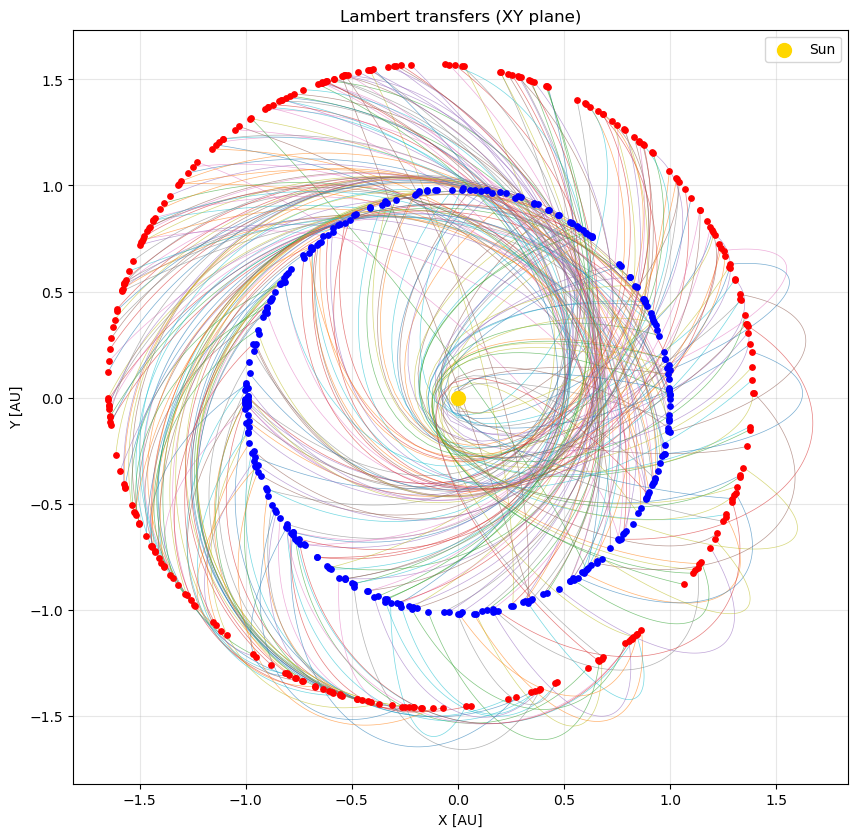

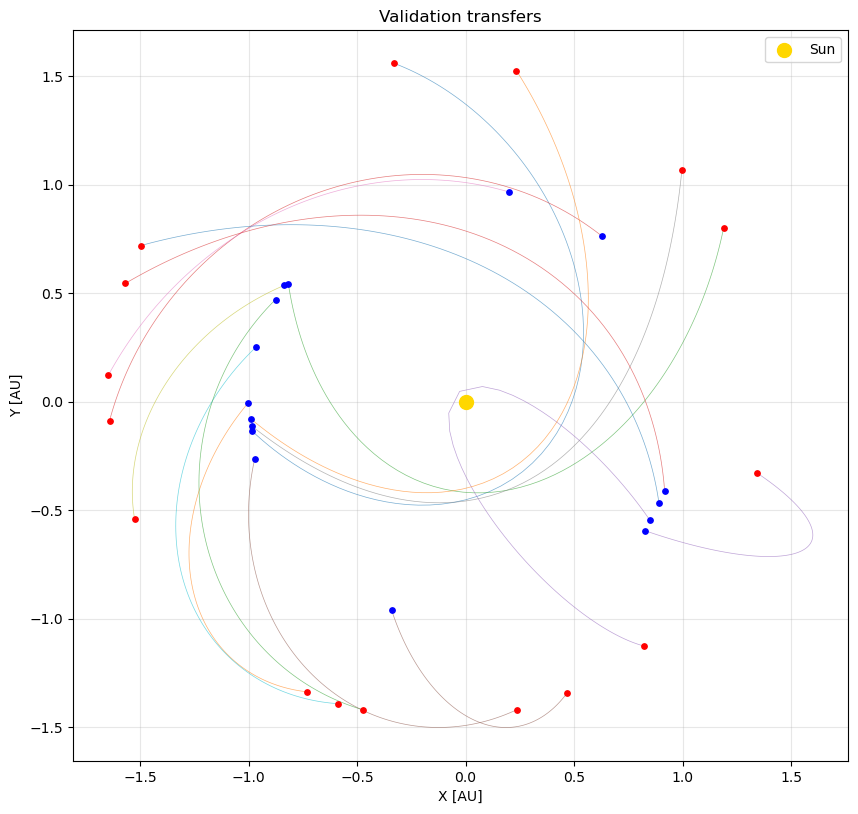

In [29]:
def plot_transfers(lamb, soi, sample_indices=None, title="Lambert transfers (XY plane)"):
    """
    lamb: (M, N+1, 6)
    soi:  (M, 2)
    sample_indices: which samples to plot, default all
    """
    AU = 1.496e11
    if sample_indices is None:
        sample_indices = range(lamb.shape[0])
    
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.scatter(0, 0, s=100, color="gold", zorder=10, label="Sun")
    
    for i in sample_indices:
        x = lamb[i, :, 0] / AU
        y = lamb[i, :, 1] / AU
        ax.plot(x, y, linewidth=0.5, alpha=0.6)
        ax.scatter(x[0], y[0], s=15, color="blue", zorder=5)   # departure
        ax.scatter(x[-1], y[-1], s=15, color="red", zorder=5)   # arrival
    
    ax.set_xlabel("X [AU]")
    ax.set_ylabel("Y [AU]")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    ax.legend()
    plt.show()

# All 80 transfers
plot_transfers(lamb, soi)

# Just the validation set (last 16)
plot_transfers(lamb, soi, sample_indices=range(64, 80), title="Validation transfers")

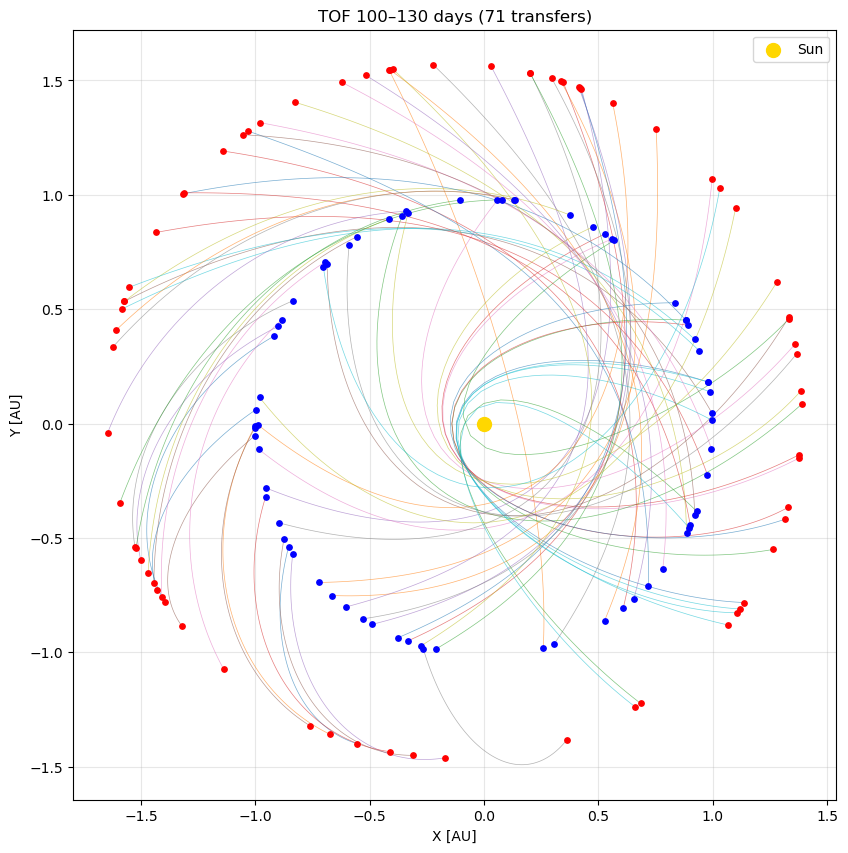

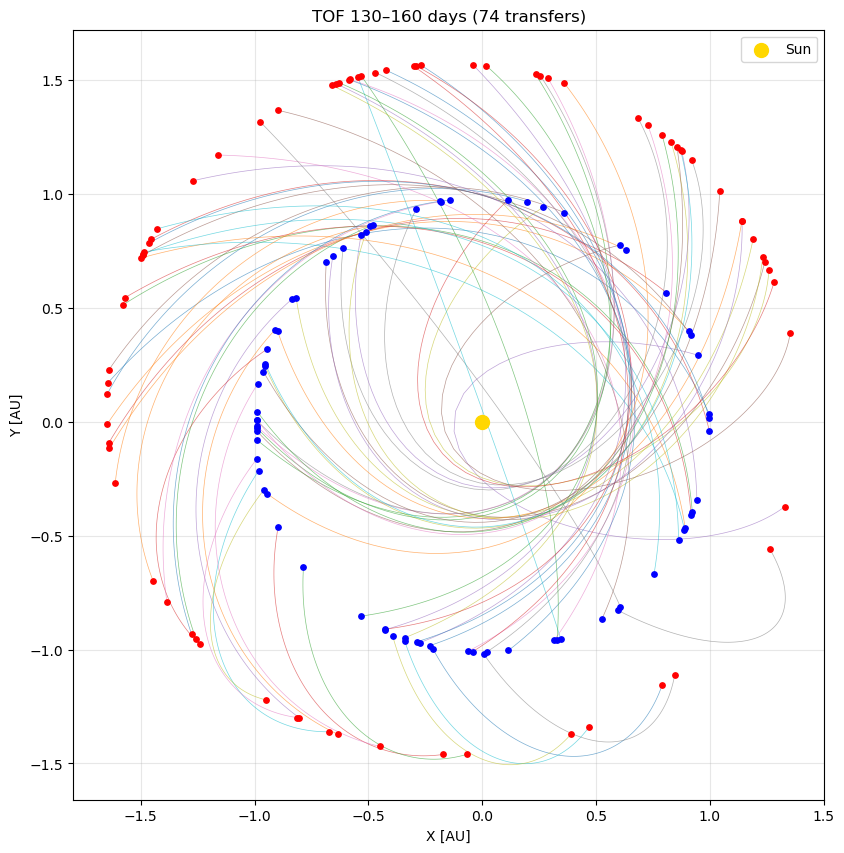

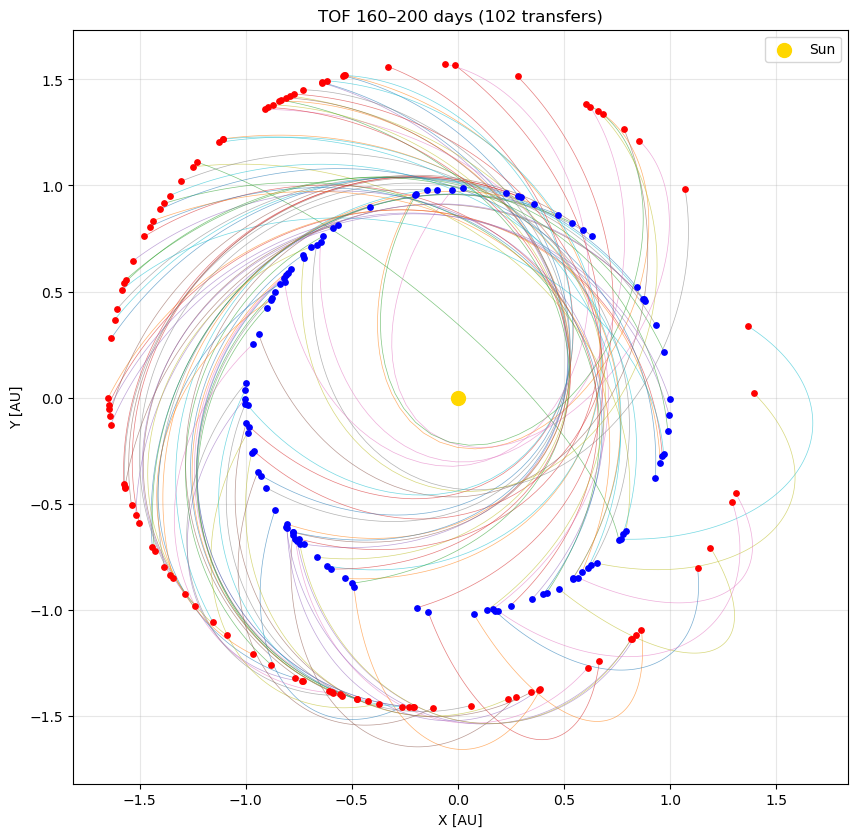

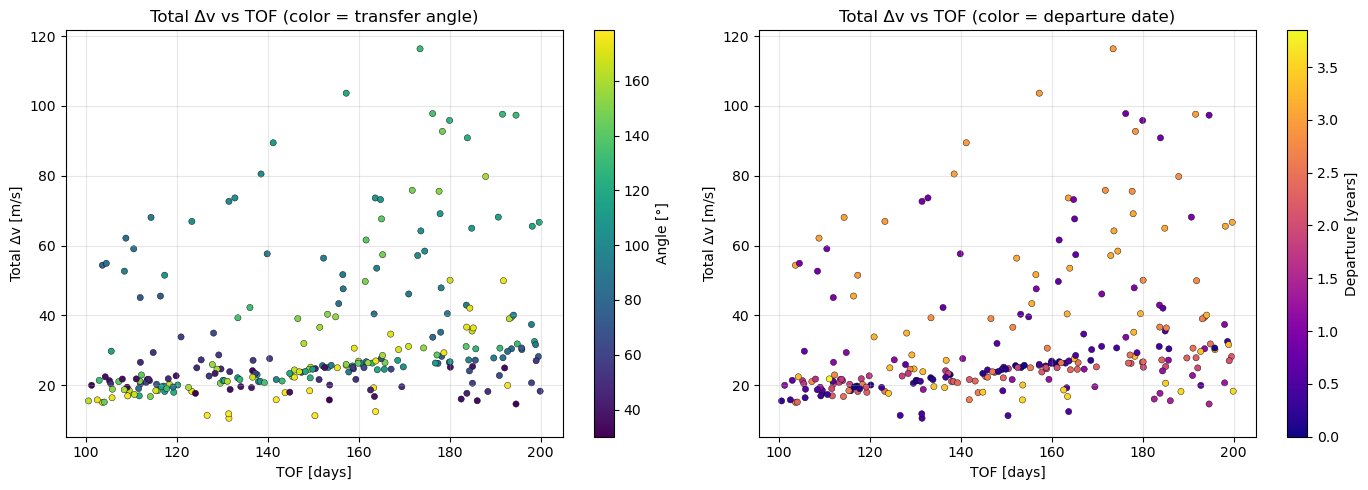

In [48]:
# ---- 1. Transfers grouped by TOF ----
tof_bins = [(100, 130), (130, 160), (160, 200)]

for lo, hi in tof_bins:
    mask = (tofs >= lo) & (tofs < hi)
    idx = np.where(mask)[0]
    plot_transfers(lamb, soi, sample_indices=idx, title=f"TOF {lo}–{hi} days ({len(idx)} transfers)")

# ---- 2. Total Dv vs TOF ----
total_dvs = np.array([np.sum(np.linalg.norm(corr[i], axis=1)) for i in range(M)])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(tofs, total_dvs, c=angles, cmap='viridis', s=20, edgecolors='k', linewidth=0.3)
axes[0].set_xlabel("TOF [days]")
axes[0].set_ylabel("Total Δv [m/s]")
axes[0].set_title("Total Δv vs TOF (color = transfer angle)")
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(angles.min(), angles.max()))
fig.colorbar(sm, ax=axes[0], label="Angle [°]")
axes[0].grid(True, alpha=0.3)

dep_years = (deps - deps.min()) / (365.25 * 86400)
axes[1].scatter(tofs, total_dvs, c=dep_years, cmap='plasma', s=20, edgecolors='k', linewidth=0.3)
axes[1].set_xlabel("TOF [days]")
axes[1].set_ylabel("Total Δv [m/s]")
axes[1].set_title("Total Δv vs TOF (color = departure date)")
sm1 = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(dep_years.min(), dep_years.max()))
fig.colorbar(sm1, ax=axes[1], label="Departure [years]")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Fourier Neural Operator for Interplanetary Transfer Correction Profiles

## 1. Problem Statement

### 1.1 The transfer

A spacecraft transfers from Earth to Mars along a heliocentric trajectory. The **Lambert problem** yields a Keplerian arc $\boldsymbol{\xi}(t)$ connecting Earth's position at departure epoch $t_0$ to Mars' position at arrival epoch $t_f = t_0 + T$, where $T$ is the time of flight:

$$\boldsymbol{\xi}(t) = \begin{pmatrix} \mathbf{r}_L(t) \\ \mathbf{v}_L(t) \end{pmatrix} \in \mathbb{R}^6, \qquad t \in [t_0, t_f]$$

This arc satisfies two-body dynamics under the Sun's gravitational parameter $\mu_\odot$ and serves as the nominal reference trajectory.

### 1.2 The domain of interest

The Lambert arc extends from the center of Earth to the center of Mars. However, within each body's **sphere of influence** (SOI), the trajectory is dominated by the local body's gravity and the heliocentric perturbation model is not appropriate. The SOI radius for body $B$ is:

$$r_{\text{SOI},B} = a_B \left(\frac{\mu_B}{\mu_\odot}\right)^{2/5}$$

where $a_B$ is the semi-major axis of body $B$'s orbit around the Sun.

We define two epochs by scanning the Lambert arc:
- $t_{\text{dep}}$: the first epoch at which the spacecraft exits Earth's SOI, i.e., $\|\mathbf{r}_L(t) - \mathbf{r}_\oplus(t)\| > r_{\text{SOI},\oplus}$
- $t_{\text{arr}}$: the last epoch at which the spacecraft is outside Mars' SOI, i.e., $\|\mathbf{r}_L(t) - \mathbf{r}_{\text(Mars)}(t)\| > r_{\text{SOI},\text(Mars)}$

The domain of interest is the heliocentric segment $[t_{\text{dep}}, t_{\text{arr}}]$. Its duration $T_{\text{SOI}} = t_{\text{arr}} - t_{\text{dep}}$ is shorter than $T$ by the time spent traversing both SOIs.

### 1.3 Perturbations

In reality, the spacecraft experiences perturbations not captured by the two-body Lambert solution:
- Point-mass gravity from Earth and Mars (heliocentric third-body effects)
- Solar radiation pressure (cannonball model with reference area $S_{\text{ref}}$ and reflectivity coefficient $C_r$)

Under these perturbations, the actual trajectory $\mathbf{x}(t)$ deviates from $\boldsymbol{\xi}(t)$. Without correction, this deviation grows monotonically: the spacecraft misses Mars.

### 1.4 Correction via impulsive maneuvers

We divide $[t_{\text{dep}}, t_{\text{arr}}]$ into $N$ sub-arcs of equal duration $\Delta t = T_{\text{SOI}} / N$, with boundary epochs:

$$t_i = t_{\text{dep}} + i \cdot \Delta t, \qquad i = 0, 1, \ldots, N$$

At the start of each arc $i$, an impulsive velocity correction $\Delta\mathbf{v}_i \in \mathbb{R}^3$ is applied. Between impulses, the spacecraft propagates under the full perturbed dynamics. The state deviation at the end of arc $i$ is:

$$\delta\mathbf{x}_i = \mathbf{x}(t_{i+1}) - \boldsymbol{\xi}(t_{i+1})$$

This deviation is carried into arc $i+1$ as the initial condition: the arcs are **sequentially coupled**. Each $\Delta\mathbf{v}_i$ is computed by solving a local linearized correction problem using the state transition matrix $\Phi(t_{i+1}, t_i)$ from the variational equations, via iterative least-squares (Gauss-Newton).

### 1.5 SOI boundary effects

The first few arcs after $t_{\text{dep}}$ and the last few before $t_{\text{arr}}$ exhibit qualitatively different behavior from the mid-transfer arcs. Near the SOI boundaries:

1. The spacecraft remains close to the departed/arriving planet, so third-body gravitational perturbations are large and rapidly varying.
2. The correction magnitudes $\|\Delta\mathbf{v}_i\|$ at boundary arcs are typically an order of magnitude larger than at mid-transfer arcs.
3. The correction profile has steep gradients near $s = 0$ and $s = 1$ that require high-frequency content to represent.

These boundary effects are physically real and must be included in any correction profile that will be applied in closed-loop propagation: omitting the boundary arcs causes the trajectory to diverge from the first arc, rendering all subsequent corrections invalid regardless of their accuracy.

## 2. Operator Learning Formulation

### 2.1 Parametrization

We introduce the normalized arc parameter $s \in [0, 1]$:

$$s = \frac{t - t_{\text{dep}}}{T_{\text{SOI}}}$$

Different transfers — characterized by different $(t_0, T)$ pairs — produce different Lambert arcs and different correction profiles, all defined on $s \in [0, 1]$.

### 2.2 Input and output functions

The **input** is the Lambert state trajectory restricted to $[t_{\text{dep}}, t_{\text{arr}}]$, viewed as a function of $s$:

$$\mathbf{u}(s) : [0, 1] \to \mathbb{R}^6, \qquad \mathbf{u}(s) = \boldsymbol{\xi}(t_{\text{dep}} + s \cdot T_{\text{SOI}})$$

This is a smooth, analytic function (a Keplerian orbit evaluated at uniformly spaced epochs). It is fully determined by the departure epoch and time of flight, and is inexpensive to evaluate via SPICE ephemerides and the Lambert solver.

The **output** is the correction acceleration profile:

$$\mathbf{a}(s) : [0, 1] \to \mathbb{R}^3, \qquad \mathbf{a}(s_i) = \frac{\Delta\mathbf{v}_i}{\Delta t}$$

The division by arc duration $\Delta t$ is essential. The impulsive correction $\Delta\mathbf{v}_i$ scales approximately linearly with $\Delta t$ (longer arcs accumulate more perturbation, requiring larger corrections). The ratio $\Delta\mathbf{v}_i / \Delta t$ is therefore approximately independent of $N$, representing the underlying continuous correction acceleration field that the impulses discretize.

### 2.3 The operator

The mapping we seek to approximate is a nonlinear operator:

$$\mathcal{G}^\dagger : \mathcal{U} \to \mathcal{A}$$
$$\mathbf{u} \mapsto \mathbf{a}$$

where $\mathcal{U} \subset L^2([0,1]; \mathbb{R}^6)$ is the space of Lambert state trajectories and $\mathcal{A} \subset L^2([0,1]; \mathbb{R}^3)$ is the space of correction acceleration profiles. Each $(t_0, T)$ pair generates one instance $(\mathbf{u}, \mathbf{a})$.

### 2.4 Validity of the operator learning formulation

For the Fourier Neural Operator framework to be applicable, three conditions must hold:

**Condition 1: Function-to-function mapping.** Both $\mathbf{u}(s)$ and $\mathbf{a}(s)$ are functions of the same continuous variable $s \in [0, 1]$, sampled on the same uniform grid. This distinguishes the problem from a boundary-value-to-function mapping, which would require a different architecture.

**Condition 2: The output is approximately a continuous function.** The correction acceleration $\mathbf{a}(s)$ is well-defined in the limit $N \to \infty$: as the arc duration shrinks, the impulsive corrections approach the continuous acceleration field that would exactly cancel the perturbation. In practice, the profile has two regimes:

- **SOI boundary regions** ($s \approx 0$ and $s \approx 1$): sharp gradients, high magnitude, dominated by nearby planetary gravity. These require high-frequency spectral content.
- **Mid-transfer** ($s \in [0.1, 0.9]$ approximately): smooth, low-frequency, dominated by slowly-varying third-body and SRP effects.

The FNO's spectral truncation (retaining $k_{\max}$ Fourier modes) naturally captures the mid-transfer structure. The boundary regions are harder to represent spectrally, but must be included for physical validity.

**Condition 3: Different samples are instances of the same operator.** The physical mechanism producing $\mathbf{a}$ from $\mathbf{u}$ is the same across all transfers: perturbation forces act deterministically as a function of position and epoch. Varying $(t_0, T)$ changes both the Lambert arc and the planetary configuration, but the underlying operator — propagate under perturbations, compute required corrections — is shared. The FNO learns this shared structure.

**A subtlety: sequential coupling.** The correction at arc $i$ was computed with knowledge of the residual state deviation $\delta\mathbf{x}_{i-1}$ inherited from arc $i-1$. Strictly, $\mathbf{a}(s_i)$ depends not only on $\mathbf{u}(s_i)$ but on the entire history $\{\mathbf{a}(s_j)\}_{j < i}$. The FNO treats $\mathbf{a}(s_i)$ as a function of $\mathbf{u}$ alone — it learns the open-loop correction profile, not the closed-loop policy. This is a valid approximation when the residual deviations $\|\delta\mathbf{x}_i\|$ are small (which holds when the corrections are effective), but limits the FNO's utility as a standalone guidance law.

## 3. Architecture

The FNO approximates $\mathcal{G}^\dagger$ as:

$$\mathcal{G}_\theta = \mathcal{Q} \circ \sigma(\mathcal{L}_2) \circ \sigma(\mathcal{L}_1) \circ \mathcal{P}$$

### 3.1 Lifting

$$\mathcal{P} : \mathbb{R}^6 \to \mathbb{R}^d$$

A pointwise linear map at each grid point, projecting the 6-dimensional state (3 position + 3 velocity) into a $d$-dimensional latent representation. Implemented as a shared $\texttt{nn.Linear}(6, d)$.

### 3.2 Fourier layers

Each layer $\ell = 1, \ldots, L$ updates the latent field $\mathbf{h}^{(\ell)}(s) \in \mathbb{R}^d$ via:

$$\mathbf{h}^{(\ell+1)}(s) = \sigma\!\left(\mathcal{K}_\ell\!\left(\mathbf{h}^{(\ell)}\right)\!(s) \;+\; W_\ell \, \mathbf{h}^{(\ell)}(s)\right)$$

where:

- $\mathcal{K}_\ell$ is a **spectral convolution**: apply the discrete Fourier transform along $s$, multiply the lowest $k_{\max}$ frequency components by a learnable complex tensor $R_\ell \in \mathbb{C}^{d \times d \times k_{\max}}$, set all higher modes to zero, and inverse-transform:

$$\mathcal{K}_\ell(\mathbf{h})(s) = \mathcal{F}^{-1}\!\left[\, R_\ell \cdot \left(\mathcal{F}[\mathbf{h}]\right)_{|k| \leq k_{\max}} \,\right](s)$$

- $W_\ell \in \mathbb{R}^{d \times d}$ is a **pointwise linear map** acting as a local skip connection. This is critical: the spectral convolution alone cannot represent pointwise (local) transformations, and the perturbation field has local structure (proximity to Earth/Mars at the boundaries).

- $\sigma$ is the GELU activation function, applied after the sum. It is omitted in the final Fourier layer ($\ell = L$) to allow the output to take any sign and magnitude.

The zeroing of high-frequency modes is what enforces spectral bias: the network preferentially learns smooth, low-frequency mappings, which matches the mid-transfer physics. The boundary regions, where the correction field has high-frequency content, are represented through the combination of retained low modes and the pointwise skip connection.

### 3.3 Projection

$$\mathcal{Q} : \mathbb{R}^d \to \mathbb{R}^3$$

A pointwise linear map producing the 3-component correction acceleration. Implemented as $\texttt{nn.Linear}(d, 3)$.

### 3.4 Discretization invariance

The learnable parameters $(R_\ell, W_\ell, \mathcal{P}, \mathcal{Q})$ are defined independently of the spatial grid size $N$. The Fourier transform and its inverse adapt to the grid: at resolution $N$, the DFT has $\lfloor N/2 \rfloor + 1$ frequency bins, of which only the lowest $k_{\max}$ are used. This means the same trained model can be evaluated at any resolution $N \geq 2 k_{\max}$ without retraining — the defining property of neural operators.

### 3.5 Hyperparameters

| Parameter | Value | Rationale |
|---|---|---|
| Fourier modes $k_{\max}$ | 12 | Sufficient for mid-transfer structure; higher modes are dominated by SOI boundaries |
| Latent width $d$ | 24 | Balances expressivity with parameter count |
| Fourier layers $L$ | 2 | The correction field is smooth; deeper networks add capacity without proportional benefit |
| Input channels | 6 | Cartesian state: position (3) + velocity (3) |
| Output channels | 3 | Correction acceleration: 3 Cartesian components |
| Total parameters | ~40k | |

## 4. Data Generation

### 4.1 Sampling

Training pairs $(\mathbf{u}_i, \mathbf{a}_i)$ are generated by solving the full Gauss-Newton correction problem for randomly sampled transfers. Departure epochs are drawn uniformly over a 4-year window (covering approximately two Earth-Mars synodic periods of ~780 days). Times of flight are drawn uniformly from $[100, 200]$ days.

### 4.2 Filtering

Not all $(t_0, T)$ pairs produce well-conditioned transfers. Three filters are applied before solving:

1. **Transfer angle filter.** The angle $\alpha$ between $\mathbf{r}_\oplus(t_0)$ and $\mathbf{r}_{\text(Mars)}(t_f)$ as seen from the Sun:

$$\alpha = \arccos\!\left(\frac{\mathbf{r}_\oplus \cdot \mathbf{r}_{\text(Mars)}}{\|\mathbf{r}_\oplus\| \, \|\mathbf{r}_{\text(Mars)}\|}\right)$$

Transfers with $\alpha < 30°$ are rejected. Near-conjunction geometry ($\alpha \to 0$) produces degenerate Lambert arcs with multi-revolution or near-rectilinear solutions.

2. **Aphelion filter.** Transfers whose Lambert arc exceeds $1.8\,\text{AU}$ in heliocentric distance are rejected. These correspond to high-energy, looping trajectories far outside the Earth-Mars corridor.

3. **Total $\Delta v$ filter.** Transfers requiring $\sum_i \|\Delta\mathbf{v}_i\| > 50\,\text{m/s}$ are rejected. High-$\Delta v$ transfers occur near unfavorable synodic windows and produce correction profiles with large-amplitude, high-frequency features that are statistically rare and disproportionately influence the loss.

### 4.3 Correction solver

For each accepted transfer, the correction profile is computed as follows. The heliocentric segment $[t_{\text{dep}}, t_{\text{arr}}]$ is divided into $N = 100$ equal arcs. For each arc $i$:

1. Propagate the variational equations (without thrust) from the current state to obtain the $6 \times 6$ state transition matrix $\Phi(t_{i+1}, t_i)$.
2. Extract the velocity-to-state block: $\Phi_v = \Phi(t_{i+1}, t_i)_{:, 3:6} \in \mathbb{R}^{6 \times 3}$.
3. Compute the state deviation without correction: $\delta\mathbf{x} = \mathbf{x}(t_{i+1}) - \boldsymbol{\xi}(t_{i+1})$.
4. Solve $\Delta\mathbf{v}_i = \arg\min_{\Delta\mathbf{v}} \|\Phi_v \, \Delta\mathbf{v} + \delta\mathbf{x}\|^2$ via least-squares.
5. Re-propagate with the correction applied. If $\|\delta\mathbf{x}_{\text{new}}\| > 1\,\text{m}$, update via Gauss-Newton and repeat.
6. Carry the residual $\delta\mathbf{x}_{\text{new}}$ into the next arc.

The output for training is $\mathbf{a}_i = \Delta\mathbf{v}_i / \Delta t$.

## 5. Training

### 5.1 Normalization

Global (dataset-wide) normalization is applied per channel:

$$\hat{u}_{i,j,c} = \frac{u_{i,j,c} - \mu_c^{(u)}}{\sigma_c^{(u)}}, \qquad \hat{a}_{i,j,c} = \frac{a_{i,j,c} - \mu_c^{(a)}}{\sigma_c^{(a)}}$$

where $\mu_c$ and $\sigma_c$ are computed over all samples $i$ and all arc points $j$ for each channel $c$. Global normalization (as opposed to per-sample) is required for deployment: the statistics are fixed at training time and do not require knowledge of the prediction target.

The raw scales differ by 15 orders of magnitude: positions are $\mathcal{O}(10^{11})\,\text{m}$, velocities are $\mathcal{O}(10^4)\,\text{m/s}$, correction accelerations are $\mathcal{O}(10^{-7})\,\text{m/s}^2$. Without per-channel normalization, the Fourier modes are dominated by position components and the output gradients vanish.

### 5.2 Loss function

Mean squared error over normalized outputs:

$$\mathcal{L}(\theta) = \frac{1}{B} \sum_{i=1}^{B} \frac{1}{N} \sum_{j=1}^{N} \left\| \hat{\mathbf{a}}_i(s_j) - \mathcal{G}_\theta(\hat{\mathbf{u}}_i)(s_j) \right\|^2$$

### 5.3 Optimization

Adam optimizer with weight decay $\lambda = 10^{-4}$ and initial learning rate $\eta = 10^{-3}$. A **hard optimizer restart** is performed at epoch 5000: the optimizer state (first and second moment estimates) is reinitialized while retaining the model weights. This clears stale curvature estimates accumulated during the first phase and allows the optimizer to re-adapt to the local loss landscape, empirically yielding a second phase of rapid descent.

### 5.4 Train/validation split

85% of samples for training, 15% for validation. The split is by trajectory, not by arc: all arcs of a given transfer are in the same set. This tests generalization to unseen departure dates and flight times.

## 6. Results

### 6.1 Baseline comparison

On held-out validation trajectories:

| Method | MSE (normalized) |
|---|---|
| Predict zero | 1.022 |
| Predict training mean | 0.916 |
| FNO | 0.066 |

The FNO achieves **93.6% improvement** over the zero baseline and **92.8%** over the training-mean baseline.

### 6.2 Physical accuracy (open-loop)

The FNO-predicted total $\Delta v$ budget, obtained by denormalizing and integrating $\|\mathbf{a}(s)\|$ over the arc, agrees with the true value:

| | Total $\Delta v$ [m/s] |
|---|---|
| True (solver) | 93.57 |
| FNO predicted | 96.93 |
| Error | 3.36 (3.6%) |

### 6.3 Discretization invariance

The FNO, trained on $N = 100$ arc points, is evaluated on the same Lambert trajectory resampled at $N = 50$, $100$, and $200$. The input is constructed by interpolating the Lambert state trajectory to the new grid and applying the same global normalization.

| $N$ | Mean $\|\mathbf{a}\|$ [m/s²] | Max $\|\mathbf{a}\|$ [m/s²] |
|---|---|---|
| 50 | $8.370 \times 10^{-7}$ | $4.914 \times 10^{-6}$ |
| 100 | $8.380 \times 10^{-7}$ | $4.926 \times 10^{-6}$ |
| 200 | $8.385 \times 10^{-7}$ | $4.911 \times 10^{-6}$ |

Agreement to three significant figures in both mean and maximum confirms that the FNO has learned the continuous operator rather than memorizing the training grid.

### 6.4 Closed-loop propagation

The definitive test: apply the FNO's predicted $\Delta\mathbf{v}_i$ corrections (including direction, not just magnitude) in a full Tudat propagation and compare the resulting trajectory deviation against the true corrections and no corrections.

| | Final $\|\delta\mathbf{r}\|$ [m] | Final $\|\delta\mathbf{v}\|$ [m/s] | Total $\Delta v$ [m/s] |
|---|---|---|---|
| True corrections | $3.15 \times 10^{-5}$ | $2.46$ | $54.92$ |
| FNO corrections | $\sim 10^{7}$–$10^{8}$ | $\sim 20$–$90$ | comparable to true |
| No corrections | $\sim 6 \times 10^{8}$ | $\sim 110$ | 0 |

The FNO reduces the final position error by approximately one order of magnitude compared to no corrections, but remains 12 orders of magnitude worse than the iterative solver. The total $\Delta v$ expenditure is comparable, indicating that the correction **magnitudes** are well-predicted but the **directions** contain errors of a few degrees that compound sequentially across 100 arcs.

### 6.5 Interpretation

The closed-loop degradation is a consequence of the sequential coupling described in Section 2.4. The FNO predicts the open-loop correction profile — the $\Delta\mathbf{v}_i$ values computed by the solver in sequence, each conditioned on the previous. When applied in closed-loop, any small error at arc $i$ shifts the state at arc $i+1$ away from what the solver assumed, making $\Delta\mathbf{v}_{i+1}$ suboptimal for the actual state. Over 100 arcs, these errors accumulate.

This is not a failure of the FNO architecture but a fundamental limitation of open-loop surrogate models applied to sequentially coupled problems. The FNO faithfully approximates the operator $\mathcal{G}^\dagger$ but cannot account for the feedback loop that the iterative solver implicitly provides.

## 7. Practical Value

The FNO surrogate is not a standalone guidance law but a **warm-start** for the iterative solver:

1. Given a new $(t_0, T)$, evaluate the Lambert arc and query the FNO to obtain an initial correction profile in milliseconds.
2. Use this profile as the starting point for the Gauss-Newton solver, which then converges in fewer iterations than starting from zero.

This is the natural role of a learned surrogate for a sequentially coupled problem: reduce the computational cost of the iterative solver by providing a good initial guess, rather than replacing the solver entirely.